In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from Post_BEAGLE_Analysis import *
from Helper_Functions import *
import seaborn as sb
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['font.family'] = 'serif'
plt.rcParams['xtick.labelsize'] = 17
plt.rcParams['ytick.labelsize'] = 17

In [3]:
LYA = 1215.67 #lya
CIV = 1549 #CIV
HEII = 1640 #HeII
NV = 1240
CIII = 1909
MGII = 2798

In [4]:
def grab_spectral_region(data_wave, data_flux, line_wave, window):

    min_window = line_wave - window
    max_window = line_wave + window
    idx = np.where((min_window < data_wave) & (data_wave < max_window))[0]

    wave = data_wave[idx]
    flux = data_flux[idx]
    
    return wave, flux

In [5]:
def read_marg_sed(bgl_output):
    
    marg_wave, marg_sed = bgl_output['marg_wvln'], bgl_output['marg_sed']
    
    return marg_wave, marg_sed

def BIC_Criterion(lnL, k, n):
    return -2 * lnL + k * np.log(n)

def compute_BIC(df):
    
    num_parameters = df.shape[1] - 4
    n_sample = df.n_data.values[0]
    
    return BIC_Criterion(df['ln_likelihood'], num_parameters, n_sample)

def compute_bic_region(bgl_output, wave, flux, fluxerr, plot = None, plot_file = None):

    model_wave, model_flux = read_marg_sed(bgl_output)
    residual = compute_residuals(wave*1e10, flux, fluxerr, model_wave, model_flux)
    chi2 = residual**2
    mask = (model_wave > 19000) & (model_wave < 26500)
    L = np.exp(-0.5*np.sum(chi2[mask]))
    lnL = np.log(L)
    n = mask.sum()
    k = len(bgl_output['posterior'].colnames) - 4
    bic = BIC_Criterion(lnL, k, n)

In [6]:
nirspec = Table.read('data/spectra/1395_Only_Spec.fits')
wave, flux, fluxerr = nirspec['wav']*1e10, nirspec['flux'], nirspec['fluxerr']

In [3]:
mup100_default = Beagle_Output('Final_Runs/AGN_Mup100_default_anshbranch_13_fixed_pl.fits.gz')

In [12]:
mup100_default = Beagle_Output('Final_Runs/AGN_Mup100_default_anshbranch_13_fixed_pl.fits.gz')
mup100_logU = Beagle_Output('Final_Runs/AGN_Mup100_logU_anshbranch_13_fixed_pl.fits.gz')
mup100_CO = Beagle_Output('Final_Runs/AGN_Mup100_Nebular_CO_Grids_anshbranch_13_fixed_pl.fits.gz')
mup100_CO_logU = Beagle_Output('Final_Runs/AGN_Mup100_Nebular_CO_Grids_w_logU_anshbranch_13_fixed_pl.fits.gz')

Mup300_default = Beagle_Output('Final_Runs/AGN_Mup300_default_anshbranch_13_fixed_pl.fits.gz')
Mup300_CO = Beagle_Output('Final_Runs/AGN_Mup300_Nebular_CO_Grids_anshbranch_13_fixed_pl.fits.gz')
Mup300_logU = Beagle_Output('Final_Runs/AGN_Mup300_logU_anshbranch_13_fixed_pl.fits.gz')
Mup300_CO_logU = Beagle_Output('Final_Runs/AGN_Mup300_Nebular_CO_Grids_w_logU_anshbranch_13_fixed_pl.fits.gz')


# SF_mup100_default = Beagle_Output('Final_Runs/SF_Mup100_Default_anshbranch_13_fixed_pl.fits.gz')
# SF_mup100_CO = Beagle_Output('Final_Runs/SF_Mup100_Nebular_CO_anshbranch_13_fixed_pl.fits.gz')

# SF_mup300_default = Beagle_Output('Final_Runs/SF_Mup300_Default_anshbranch_13_fixed_pl.fits.gz')
# SF_mup300_CO = Beagle_Output('Final_Runs/SF_Mup300_Nebular_CO_anshbranch_13_fixed_pl.fits.gz')



In [13]:
hdu_sf_default = fits.open('Final_Runs/SF_Mup100_Default_anshbranch_13_fixed_pl.fits.gz')
hdu_sf_100_co = fits.open('Final_Runs/SF_Mup100_Nebular_CO_anshbranch_13_fixed_pl.fits.gz')
hdu_sf_300_default = fits.open('Final_Runs/SF_Mup300_Default_anshbranch_13_fixed_pl.fits.gz')
hdu_sf_300_co = fits.open('Final_Runs/SF_Mup300_Nebular_CO_anshbranch_13_fixed_pl.fits.gz')

In [20]:
sf_wvln = hdu_sf_default['MARGINAL SED WL'].data[0][0]
sf_seds = hdu_sf_default['MARGINAL SED'].data

In [21]:
sf_wvln_100_co = hdu_sf_100_co['MARGINAL SED WL'].data[0][0]
sf_seds_100_co = hdu_sf_100_co['MARGINAL SED'].data

sf_wvln_300_default = hdu_sf_300_default['MARGINAL SED WL'].data[0][0]
sf_seds_300_default = hdu_sf_300_default['MARGINAL SED'].data

sf_wvln_300_co = hdu_sf_300_co['MARGINAL SED WL'].data[0][0]
sf_seds_300_co = hdu_sf_300_co['MARGINAL SED'].data

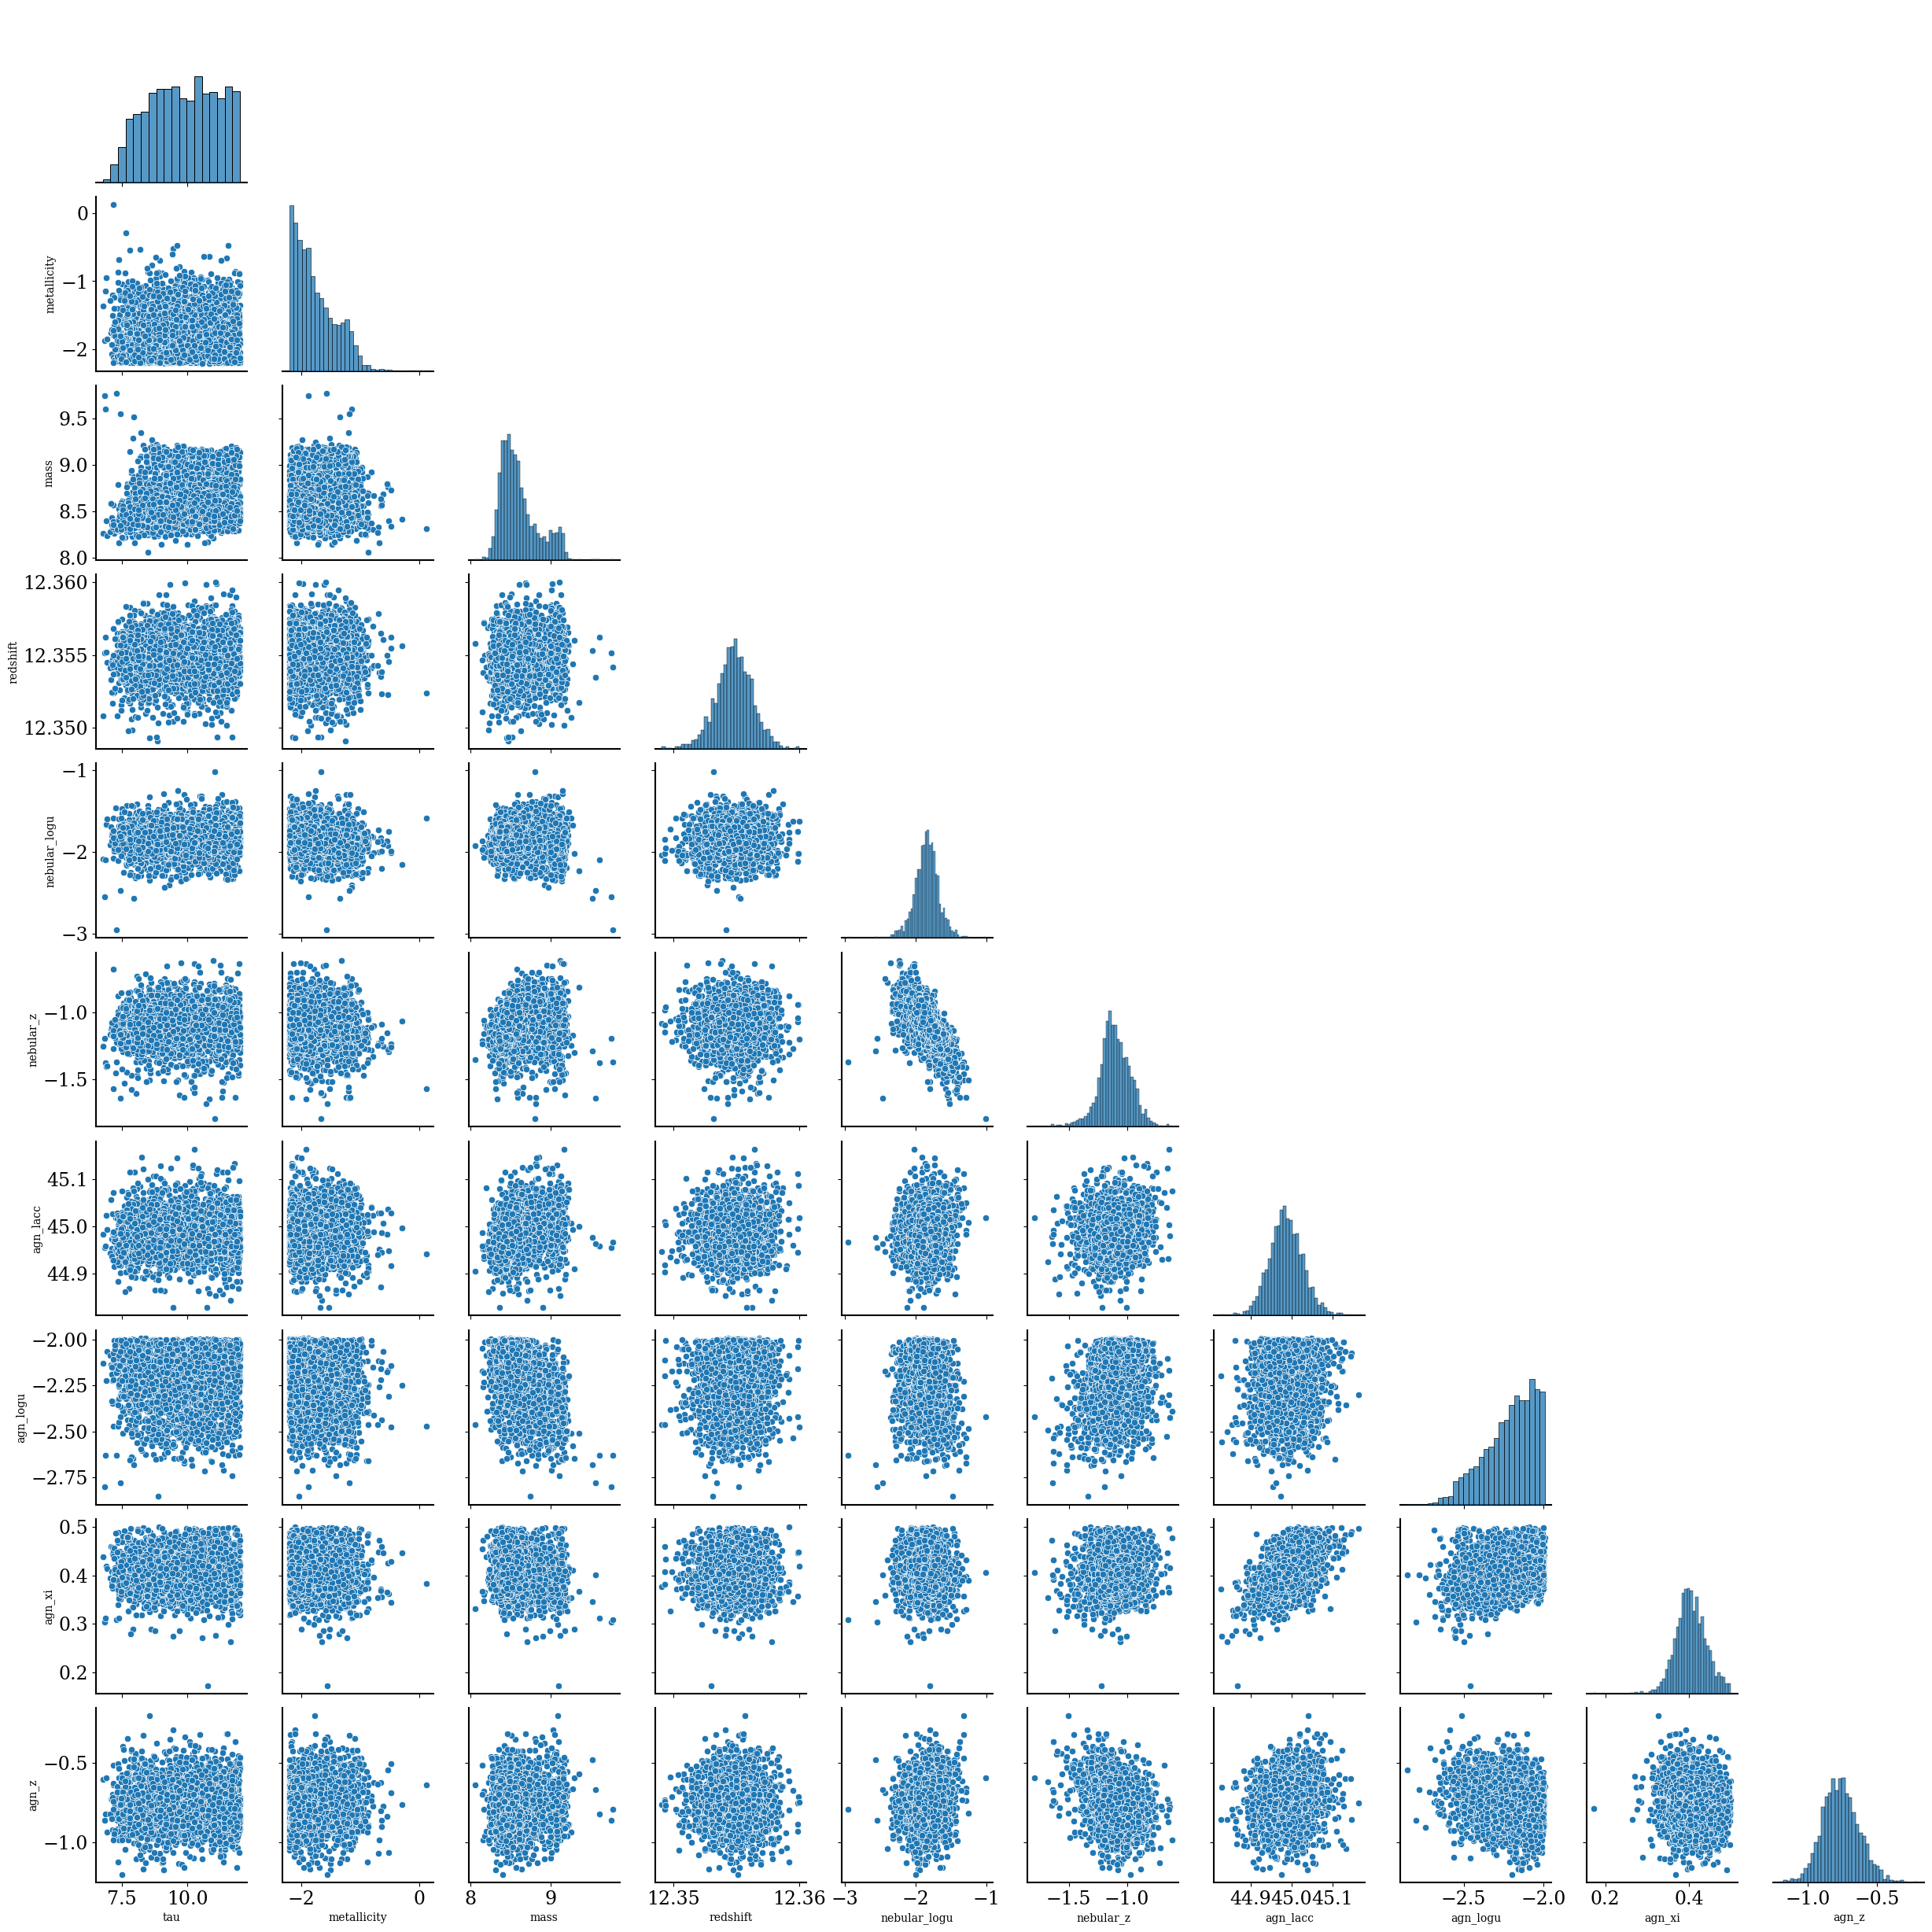

In [14]:
useful_cols = ['tau','metallicity','mass','redshift','nebular_logu','nebular_z',
               'agn_lacc','agn_logu','agn_xi','agn_z']

sb.pairplot(mup100_logU['posterior'][useful_cols].to_pandas(), corner = True)

In [15]:
mup100_logU['posterior'].colnames

['probability',
 'ln_likelihood',
 'chi_square',
 'n_data',
 'tau',
 'metallicity',
 'mass',
 'max_stellar_age',
 'specific_sfr',
 'current_sfr_timescale',
 'redshift',
 'nebular_logu',
 'nebular_z',
 'tauv_eff',
 'agn_lacc',
 'agn_logu',
 'agn_xi',
 'agn_z']

In [13]:
# plt.figure(figsize = (12, 7))
# plt.step(wave, flux, where= 'mid', color = 'black')
# plt.step(mup100_default['marg_wvln'], np.median(mup100_default['marg_sed'], axis = 0), 
#          where = 'mid', color = 'red', label = 'Mup100 Default')

# # plt.step(mup100_CO['marg_wvln'], np.median(mup100_CO['marg_sed'], axis = 0), 
# #          where = 'mid', color = 'blue', label = 'Mup100 CO')

# # plt.step(mup100_CO_logU['marg_wvln'], np.median(mup100_CO_logU['marg_sed'], axis = 0), 
# #          where = 'mid', color = 'purple', label = 'Mup100 CO + logU')

# # plt.step(Mup300_logU['marg_wvln'], np.median(Mup300_logU['marg_sed'], axis = 0), 
# #          where = 'mid', color = 'yellow', label = 'Mup300 logU', alpha = 0.5)


# plt.step(sf_wvln, np.median(sf_seds, axis = 0), 
#          where = 'mid', color = 'blue', label = 'SF100 Default', alpha = 0.5)

# # plt.step(sf_wvln_100_co, np.median(sf_seds_100_co, axis = 0), 
# #          where = 'mid', color = 'salmon', label = 'SF100 CO', alpha = 0.5)

# # plt.step(sf_wvln_300_default, np.median(sf_seds_300_default, axis = 0), 
# #          where = 'mid', color = 'dodgerblue', label = 'SF300 Default', alpha = 0.5)

# # plt.step(sf_wvln_300_co, np.median(sf_seds_300_co, axis = 0), 
# #          where = 'mid', color = 'green', label = 'SF300 CO', alpha = 0.5)

# plt.xlabel('Observed Wavelength')
# plt.ylabel('Flux')
# plt.ylim(-0.5e-20, 1.2e-20)
# plt.legend(ncols = 2)

In [72]:
sf_cols = ['tau',
             'metallicity',
             'mass',
             'max_stellar_age',
             'specific_sfr',
             'current_sfr_timescale',
             'redshift',
             'nebular_logu',
             'nebular_z',
             'tauv_eff']

In [ ]:
sb.pairplot(Table(hdu_sf_default['POSTERIOR PDF'].data)[sf_cols].to_pandas(), corner = True, plot_kws={'alpha':0.5})



In [13]:
def read_dispersion_curve():

    tab = Table.read('data/jwst_nirspec_prism_disp.fits')
    rwave, R = tab['WAVELENGTH'], tab['R']

    return rwave, R

In [14]:
rwave, R = read_dispersion_curve()

In [15]:
def quick_agn_fraction(bgl_output, rwave, R, data_wave):
    #z = 12.34
    zp1 = 13.34
    
    model_spec = bgl_output['full_sed']
    rest_frame_model_wave = bgl_output['full_sed_wvln']
    
    obs_model_wave = rest_frame_model_wave*zp1
    
    agn_spec = bgl_agn['agn_sed']
    
    median_full_sed = np.percentile(model_spec, q = 50, axis = 0)

    median_agn_sed = np.percentile(agn_spec, q = 50, axis = 0)

    conv_full_sed = bgl_output.convolve_model_spec(rwave, R, obs_model_wave, median_full_sed, data_wave, oversample = 75)
    conv_agn_sed = bgl_output.convolve_model_spec(rwave, R, obs_model_wave, median_agn_sed, data_wave, oversample = 75)

    fagn = conv_agn_sed/conv_full_sed

    return fagn

In [144]:
fagn_mup300 = quick_agn_fraction(bgl_agn, rwave*1e4, R, wave)
fagn_mup100 = quick_agn_fraction(bgl_agn_default, rwave*1e4, R, wave)

/var/folders/t2/6968g8md2c9g1mm1h0p9nxl588s4s1/T/ipykernel_83740/4152286091.py:19: RuntimeWarning: invalid value encountered in divide
  fagn = conv_agn_sed/conv_full_sed


In [147]:
wave_agn, flux_agn = grab_spectral_region(wave/13.34, fagn_mup300, CIV, 50)
wave_default, flux_default = grab_spectral_region(wave/13.34, fagn_mup100, CIV, 50)

In [16]:
def generate_component_specs_plot(bgl_output, data_wave, data_flux, data_flux_err):
    
    MAX_IDX = np.argmax(bgl_output['posterior']['probability'])

    zp1 = 1+bgl_output['gal_prop']['redshift'][MAX_IDX]
    #print(bgl_output['z'])
    mult_factor = 1e20

    og_full_sed = bgl_output['full_sed']/zp1 #convert to observed frame
    og_agn_sed = bgl_output['agn_sed']/zp1   #convert to observed frame
    marg_wave = bgl_output['marg_wvln']

    og_agn_l16, og_agn_med, og_agn_u84 = np.percentile(og_agn_sed*mult_factor, q = (16, 50, 84), axis = 0)
    og_spec_l16, og_spec_med, og_spec_u84 = np.percentile(og_full_sed*mult_factor, q = (16, 50, 84), axis = 0)
    og_wave = bgl_output['full_sed_wvln'] * zp1

    spec_med = bgl_output.convolve_model_spec(rwave, R, og_wave, og_spec_med, marg_wave, oversample = 75)
    spec_l16 = bgl_output.convolve_model_spec(rwave, R, og_wave, og_spec_l16, marg_wave, oversample = 75)
    spec_u84 = bgl_output.convolve_model_spec(rwave, R, og_wave, og_spec_u84, marg_wave, oversample = 75)
    
    agn_med = bgl_output.convolve_model_spec(rwave, R, og_wave, og_agn_med, marg_wave, oversample = 75)
    agn_l16 = bgl_output.convolve_model_spec(rwave, R, og_wave, og_agn_l16, marg_wave, oversample = 75)
    agn_u84 = bgl_output.convolve_model_spec(rwave, R, og_wave, og_agn_u84, marg_wave, oversample = 75)
    
    conv_wave = marg_wave
    
    og_mask = (og_wave >= conv_wave[0]) & (og_wave <= conv_wave[-1])

    diff_spec_l16 = spec_l16 - agn_l16
    diff_spec_med = spec_med - agn_med
    diff_spec_u84 = spec_u84 - agn_u84
    
    # Create a figure
    fig = plt.figure(figsize=(25, 10), dpi = 200)
    
    # Create a grid with 3 rows and 4 columns using gridspec
    gs = fig.add_gridspec(1, 1)

    ax = fig.add_subplot(gs[0])

    ax.step(conv_wave, agn_med, label = 'Model AGN SED', color = 'dodgerblue', where = 'mid', zorder = 200)
    ax.fill_between(conv_wave, agn_u84, agn_l16, step = 'mid', color = 'dodgerblue')
    
    ax.step(conv_wave, spec_med, label = 'Model SF+AGN SED', color = 'purple', where = 'mid', zorder = 202)
    ax.fill_between(conv_wave, spec_u84, spec_l16, step = 'mid', color = 'purple')
    
    ax.step(conv_wave, diff_spec_med, label = 'Stellar+HII Region SED', color = 'red', where = 'mid', zorder = 200)
    ax.fill_between(conv_wave, diff_spec_u84, diff_spec_l16, step = 'mid', color = 'red')

    ax.step(data_wave, data_flux*mult_factor, color = 'black', where = 'mid', alpha = 0.7, label = 'Data')
    ax.errorbar(data_wave, data_flux*mult_factor, yerr = data_flux_err*mult_factor, color = 'gray', fmt = 'none')

    ax.set_ylabel(r'F$_{\nu}$ [1$\times$10$^{-20}$ erg s$^{-1}$cm$^2$$\AA$$^{-1}$]', fontsize = 30)
    ax.set_xlabel(r'Observed Wavelength [$\AA$]', fontsize = 30)
    obs_ticks = ax.get_xticks()
    ax.set_xticks(obs_ticks)
    ax.set_xticklabels(obs_ticks, fontsize = 30)
    ax.legend(fontsize = 30)

    ax2 = ax.twiny()

    obs_xlim = ax.get_xlim()
    rest_xlim = [x / zp1 for x in obs_xlim]  # Convert to rest-frame
    ax2.set_xlim(rest_xlim)

    obs_ticks = ax.get_xticks()
    rest_ticks = [tick / zp1 for tick in obs_ticks]
    ax2.set_xticks(rest_ticks)
    ax2.set_xticklabels([f"{tick:.0f}" for tick in rest_ticks], fontsize = 30)
    ax2.set_xlabel(r"Rest Frame Wavelengths [$\AA$]", fontsize = 30)

    offset = 40*zp1
    ax.annotate(r'CIV', (1548.187*zp1 - offset, 1.45), fontsize = 25)

    ax.annotate(r'CIII]', (1908.734	*zp1 - offset, .8), fontsize = 25)

    ax.annotate(r'MgII', (2795.528*zp1 - offset, .3), fontsize = 25)

    ax.annotate(r'HeII', (1640.420*zp1 - offset, .9), fontsize = 25)

    ax.annotate(r'[NeIII]', ((3868.760*zp1) - 800, .75), fontsize = 25)
    
    ax.set_ylim(-0.25, 1.55)
    ax.set_xlim(15000, 55000)
    
    return fig, [ax, ax2]

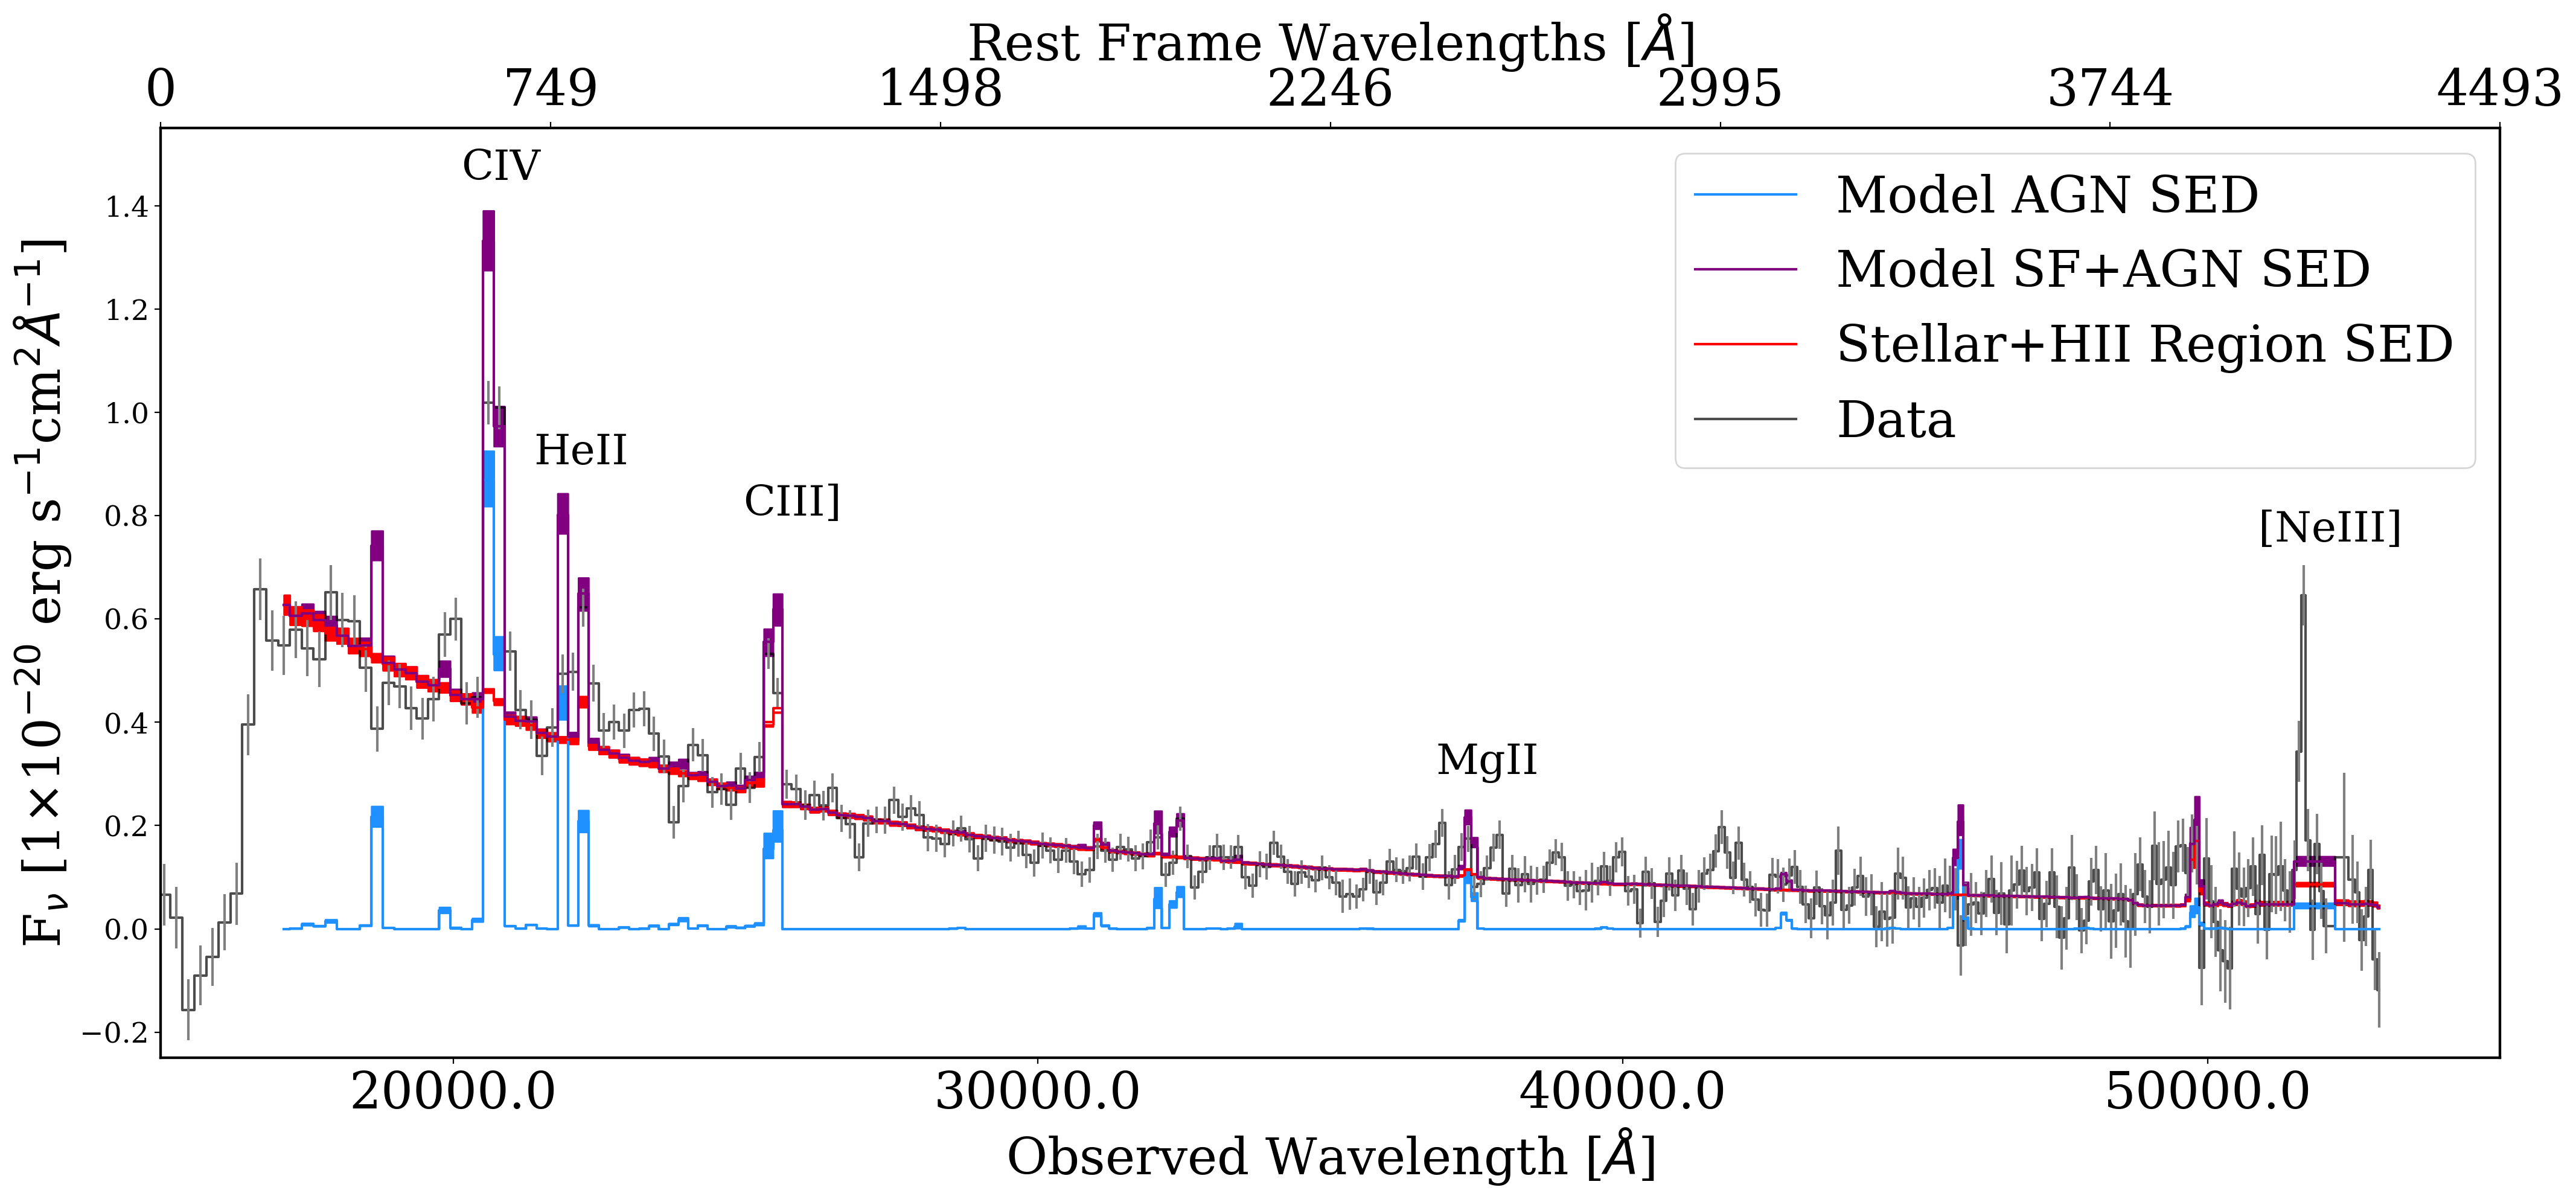

In [22]:
fig, axes = generate_component_specs_plot(mup100_logU, wave, flux, fluxerr)

In [18]:
wave/13.34

489.0236633327161
493.204382878066
497.4823463341307
501.86010074663295
506.3476387666791
510.94897728182286
515.6592570839946
520.4808641890105
525.4295385424707
530.5049430711326
535.7009838103108


In [80]:
#fig.savefig('Final_Plots/Composite_Plot.png', dpi = 300)

In [81]:
# def test(bgl_output, data_wave, data_flux, data_flux_err):
    
#     MAX_IDX = np.argmax(bgl_output['posterior']['probability'])

#     zp1 = 1+bgl_output['gal_prop']['redshift'][MAX_IDX]
#     #print(bgl_output['z'])
#     mult_factor = 1e20

#     og_full_sed = bgl_output['full_sed']/zp1 #convert to observed frame
#     og_agn_sed = bgl_output['agn_sed']/zp1   #convert to observed frame
#     marg_wave = bgl_output['marg_wvln']

#     og_agn_l16, og_agn_med, og_agn_u84 = np.percentile(og_agn_sed*mult_factor, q = (16, 50, 84), axis = 0)
#     og_spec_l16, og_spec_med, og_spec_u84 = np.percentile(og_full_sed*mult_factor, q = (16, 50, 84), axis = 0)
#     og_wave = bgl_output['full_sed_wvln'] * zp1

#     spec_med = bgl_output.convolve_model_spec(rwave, R, og_wave, og_spec_med, marg_wave, oversample = 75)
#     spec_l16 = bgl_output.convolve_model_spec(rwave, R, og_wave, og_spec_l16, marg_wave, oversample = 75)
#     spec_u84 = bgl_output.convolve_model_spec(rwave, R, og_wave, og_spec_u84, marg_wave, oversample = 75)
    
#     agn_med = bgl_output.convolve_model_spec(rwave, R, og_wave, og_agn_med, marg_wave, oversample = 75)
#     agn_l16 = bgl_output.convolve_model_spec(rwave, R, og_wave, og_agn_l16, marg_wave, oversample = 75)
#     agn_u84 = bgl_output.convolve_model_spec(rwave, R, og_wave, og_agn_u84, marg_wave, oversample = 75)
    
#     conv_wave = marg_wave
    
#     og_mask = (og_wave >= conv_wave[0]) & (og_wave <= conv_wave[-1])

#     diff_spec_l16 = spec_l16 - agn_l16
#     diff_spec_med = spec_med - agn_med
#     diff_spec_u84 = spec_u84 - agn_u84
    
#     # Create a figure
#     fig = plt.figure(figsize=(25, 10), dpi = 200)
    
#     # Create a grid with 3 rows and 4 columns using gridspec
#     gs = fig.add_gridspec(1, 1)

#     ax = fig.add_subplot(gs[0])

#     #ax.step(conv_wave, agn_med, label = 'Model AGN SED', color = 'dodgerblue', where = 'mid', zorder = 200)
#     #ax.fill_between(conv_wave, agn_u84, agn_l16, step = 'mid', color = 'dodgerblue')
    
#     ax.step(conv_wave, spec_med, label = 'Model SF+AGN SED', color = 'purple', where = 'mid', zorder = 202, alpha = 0.5)
#     #ax.fill_between(conv_wave, spec_u84, spec_l16, step = 'mid', color = 'purple')
    
#     #ax.step(conv_wave, diff_spec_med, label = 'Stellar+HII Region SED', color = 'red', where = 'mid', zorder = 200)
#     #ax.fill_between(conv_wave, diff_spec_u84, diff_spec_l16, step = 'mid', color = 'red')

#     ax.step(data_wave, data_flux*mult_factor, color = 'black', where = 'mid', alpha = 0.7, label = 'Data')
#     ax.errorbar(data_wave, data_flux*mult_factor, yerr = data_flux_err*mult_factor, color = 'gray', fmt = 'none')

#     ax.step(conv_wave, np.percentile(bgl_output['marg_sed']*mult_factor, q = 50, axis = 0), color = 'orange')
    
#     ax.set_ylabel(r'F$_{\nu}$ [1$\times$10$^{-20}$ erg s$^{-1}$cm$^2$$\AA$$^{-1}$]', fontsize = 20)
#     ax.set_xlabel(r'Observed Wavelength [$\AA$]', fontsize = 20)
#     ax.legend(fontsize = 20)


    
#     ax.set_ylim(-0.25, 1.5)
#     ax.set_xlim(15000, 55000)
    
#     return fig, [ax]

In [82]:
# test(bgl_agn_default, wave, flux, fluxerr)

In [28]:
def read_agn_df():

    #agn_df = pd.read_csv('/Users/oac466/Downloads/jwst_blagn_10_28_2024_Machine_Readable.csv')
    agn_df = pd.read_csv('/Users/oac466/Downloads/jwst-blagn-table-2025-05-13.csv')
    agn_df = agn_df.drop(index = 0).reset_index()
    agn_df = agn_df.drop(columns=['index'])

    agn_df['m_bh'] = agn_df.m_bh.values.astype(float)
    agn_df['m_star'] = agn_df.m_star.values.astype(float)
    agn_df['m_bh_err_plus'] = agn_df.m_bh_err_plus.values.astype(float)
    agn_df['m_bh_err_minus'] = agn_df.m_bh_err_minus.values.astype(float)
    agn_df['m_star_err_plus'] = agn_df.m_bh_err_plus.values.astype(float)
    agn_df['m_star_err_minus'] = agn_df.m_bh_err_minus.values.astype(float)
    
    return agn_df


In [29]:
agn_df = read_agn_df()

In [50]:
def error_propagate_log10(err, A = 1):

    return np.abs(err/(A*np.log(10)))

In [49]:
logMBH = np.log10(agn_df.m_bh.values)
log_mstar = np.log10(agn_df.m_star.values)

In [51]:
lower_error = np.log10(agn_df.m_bh.values/(agn_df.m_bh.values - agn_df.m_bh_err_minus.values))
upper_error = np.log10((agn_df.m_bh.values + agn_df.m_bh_err_plus.values)/(agn_df.m_bh.values))

In [52]:
def get_errors_log10(val, lower_err, upper_err):

    lower_error = np.log10(val/(val - lower_err))
    upper_error = np.log10((val + upper_err)/val)

    return lower_error, upper_error

In [41]:
from astropy.cosmology import FlatLambdaCDM

In [42]:
cosmo = FlatLambdaCDM(H0 = 70, Om0 = 0.3)

In [43]:
zgrid = np.linspace(35, 4, 1000)
N = 5000

# DCBH: initial mass ~1e4-1e5 Msun at z~10-20, growing at the Eddington rate
edd_dcbh = np.zeros((N,len(zgrid)))
log_seed_mass = np.random.uniform(4,5,size=N)
seed_mass = np.power(10., log_seed_mass)
z_init = np.random.uniform(10,20, size=N)
tgrid = cosmo.age(zgrid).to(u.Gyr).value
t_init = cosmo.age(z_init).to(u.Gyr).value

lam, epsilon = 1, 0.1
tau = (4.5e8 * epsilon/(lam*(1-epsilon)))/1e9
for i in tqdm(range(N)):
    edd_dcbh[i,:] = seed_mass[i] * np.exp((tgrid-t_init[i])/tau)

edd_dcbh2 = np.zeros((N,len(zgrid)))
log_seed_mass = np.random.uniform(5,6,size=N)
seed_mass = np.power(10., log_seed_mass)
z_init = np.random.uniform(10,20, size=N)
tgrid = cosmo.age(zgrid).to(u.Gyr).value
t_init = cosmo.age(z_init).to(u.Gyr).value

lam, epsilon = 1, 0.1
tau = (4.5e8 * epsilon/(lam*(1-epsilon)))/1e9
for i in tqdm(range(N)):
    edd_dcbh2[i,:] = seed_mass[i] * np.exp((tgrid-t_init[i])/tau)

edd_dcbh3 = np.zeros((N,len(zgrid)))
log_seed_mass = np.random.uniform(6,7,size=N)
seed_mass = np.power(10., log_seed_mass)
z_init = np.random.uniform(10,20, size=N)
tgrid = cosmo.age(zgrid).to(u.Gyr).value
t_init = cosmo.age(z_init).to(u.Gyr).value

lam, epsilon = 1, 0.1
tau = (4.5e8 * epsilon/(lam*(1-epsilon)))/1e9
for i in tqdm(range(N)):
    edd_dcbh3[i,:] = seed_mass[i] * np.exp((tgrid-t_init[i])/tau)

# stellar/PopIII: initial mass ~10-300 Msun at z~15-30, growing at the eddington limit
edd_stellar = np.zeros((N,len(zgrid)))
log_seed_mass = np.random.uniform(1,2.47,size=N)
seed_mass = np.power(10., log_seed_mass)
z_init = np.random.uniform(15,30, size=N)
tgrid = cosmo.age(zgrid).to(u.Gyr).value
t_init = cosmo.age(z_init).to(u.Gyr).value
lam, epsilon = 1, 0.1
tau = (4.5e8 * epsilon/(lam*(1-epsilon)))/1e9
for i in tqdm(range(N)):
    edd_stellar[i,:] = seed_mass[i] * np.exp((tgrid-t_init[i])/tau)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 71597.39it/s]


In [44]:
edd_dcbh4 = np.zeros((N,len(zgrid)))
log_seed_mass = np.random.uniform(5,6,size=N)
seed_mass = np.power(10., log_seed_mass)
z_init = np.random.uniform(10,20, size=N)
tgrid = cosmo.age(zgrid).to(u.Gyr).value
t_init = cosmo.age(z_init).to(u.Gyr).value

lam, epsilon = 2, 0.1
tau = (4.5e8 * epsilon/(lam*(1-epsilon)))/1e9
for i in tqdm(range(N)):
    edd_dcbh4[i,:] = seed_mass[i] * np.exp((tgrid-t_init[i])/tau)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 68953.05it/s]


In [45]:
# bgl_agn_default.generate_corner_plot()

In [46]:
edd_dcbh5 = np.zeros((N,len(zgrid)))
log_seed_mass = np.random.uniform(5,6,size=N)
seed_mass = np.power(10., log_seed_mass)
z_init = np.random.uniform(10,30, size=N)
tgrid = cosmo.age(zgrid).to(u.Gyr).value
t_init = cosmo.age(z_init).to(u.Gyr).value

lam, epsilon = 1, 0.1
tau = (4.5e8 * epsilon/(lam*(1-epsilon)))/1e9
for i in tqdm(range(N)):
    edd_dcbh5[i,:] = seed_mass[i] * np.exp((tgrid-t_init[i])/tau)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 67967.10it/s]


In [109]:
# fig, ax = plt.subplots()
# ax.fill_between(zgrid, np.percentile(edd_dcbh, 16, axis=0), np.percentile(edd_dcbh, 84, axis=0), edgecolor='none', facecolor='blue', alpha=0.15, zorder=-2000)
# ax.plot(zgrid, np.percentile(edd_dcbh, 50, axis=0), c='blue', lw=1, ls='--', label='DCBH Eddington Growth')
# ax.fill_between(zgrid, np.percentile(edd_stellar, 16, axis=0), np.percentile(edd_stellar, 84, axis=0), edgecolor='none', facecolor='orange', alpha=0.3, zorder=-2000)
# ax.plot(zgrid, np.percentile(edd_stellar, 50, axis=0), c='orange', lw=1, ls='--', label='DCBH Eddington Growth')
# ax.set_yscale('log')
# ax.set_xlim(4, 11)
# ax.invert_xaxis()
# ax.set_ylim(1e6, 1e10)

In [47]:
def mbh_mstar_relation():

    m_star = np.linspace(7.5, 11, 1000)
    lines = np.zeros((1000, 1000))
    for i in range(1000):
        coeffs = np.random.normal(loc = [1.12, -2.54], scale = [0.08, 0.75])
    
        equation = coeffs[0] * m_star + (coeffs[1])
        lines[i] = equation
    return m_star, lines

def BH_Mass_estimates(bgl_output, eddington_ratio = 1):

    logLacc = np.array(bgl_output['agn_emission']['lacc_AGN']).astype(float)
    L_erg_s = (10**logLacc) * u.erg/u.s
    L_Lsun = L_erg_s.to(u.Lsun)

    Mass = L_Lsun/(3.2e4 * (u.Lsun/u.M_sun))/ eddington_ratio
    return Mass

def local_relation_bhmass():

    alpha = 7.45
    alpha_err = 0.08
    beta = 1.05
    beta_err = 0.11

    rand_alphas = np.random.normal(alpha, alpha_err, size = 1000)
    rand_betas = np.random.normal(beta, beta_err, size = 1000)

    Mstar = np.logspace(7.5, 11, 1000)
    Mstar_matrix = np.log10(np.stack([Mstar for x in range(1000)])/1e11)

    lines = Mstar_matrix *rand_betas.reshape(-1, 1) + rand_alphas.reshape(-1, 1)
    #print(lines)
    l16, med, u84 = np.percentile(lines, q = (16, 50, 84), axis = 0)
    
    return l16, med, u84, Mstar, lines 

In [25]:
MBH_edd1 = np.median(np.log10(BH_Mass_estimates(mup100_logU, eddington_ratio = 1).value)[-100:])
MBH_edd05 = np.median(np.log10(BH_Mass_estimates(mup100_logU, eddington_ratio = 0.5).value)[-100:])
MBH_edd01 = np.median(np.log10(BH_Mass_estimates(mup100_logU, eddington_ratio = 0.1).value)[-100:])


In [26]:
MBH_edd2 = np.median(np.log10(BH_Mass_estimates(mup100_logU, eddington_ratio = 10).value)[-100:])

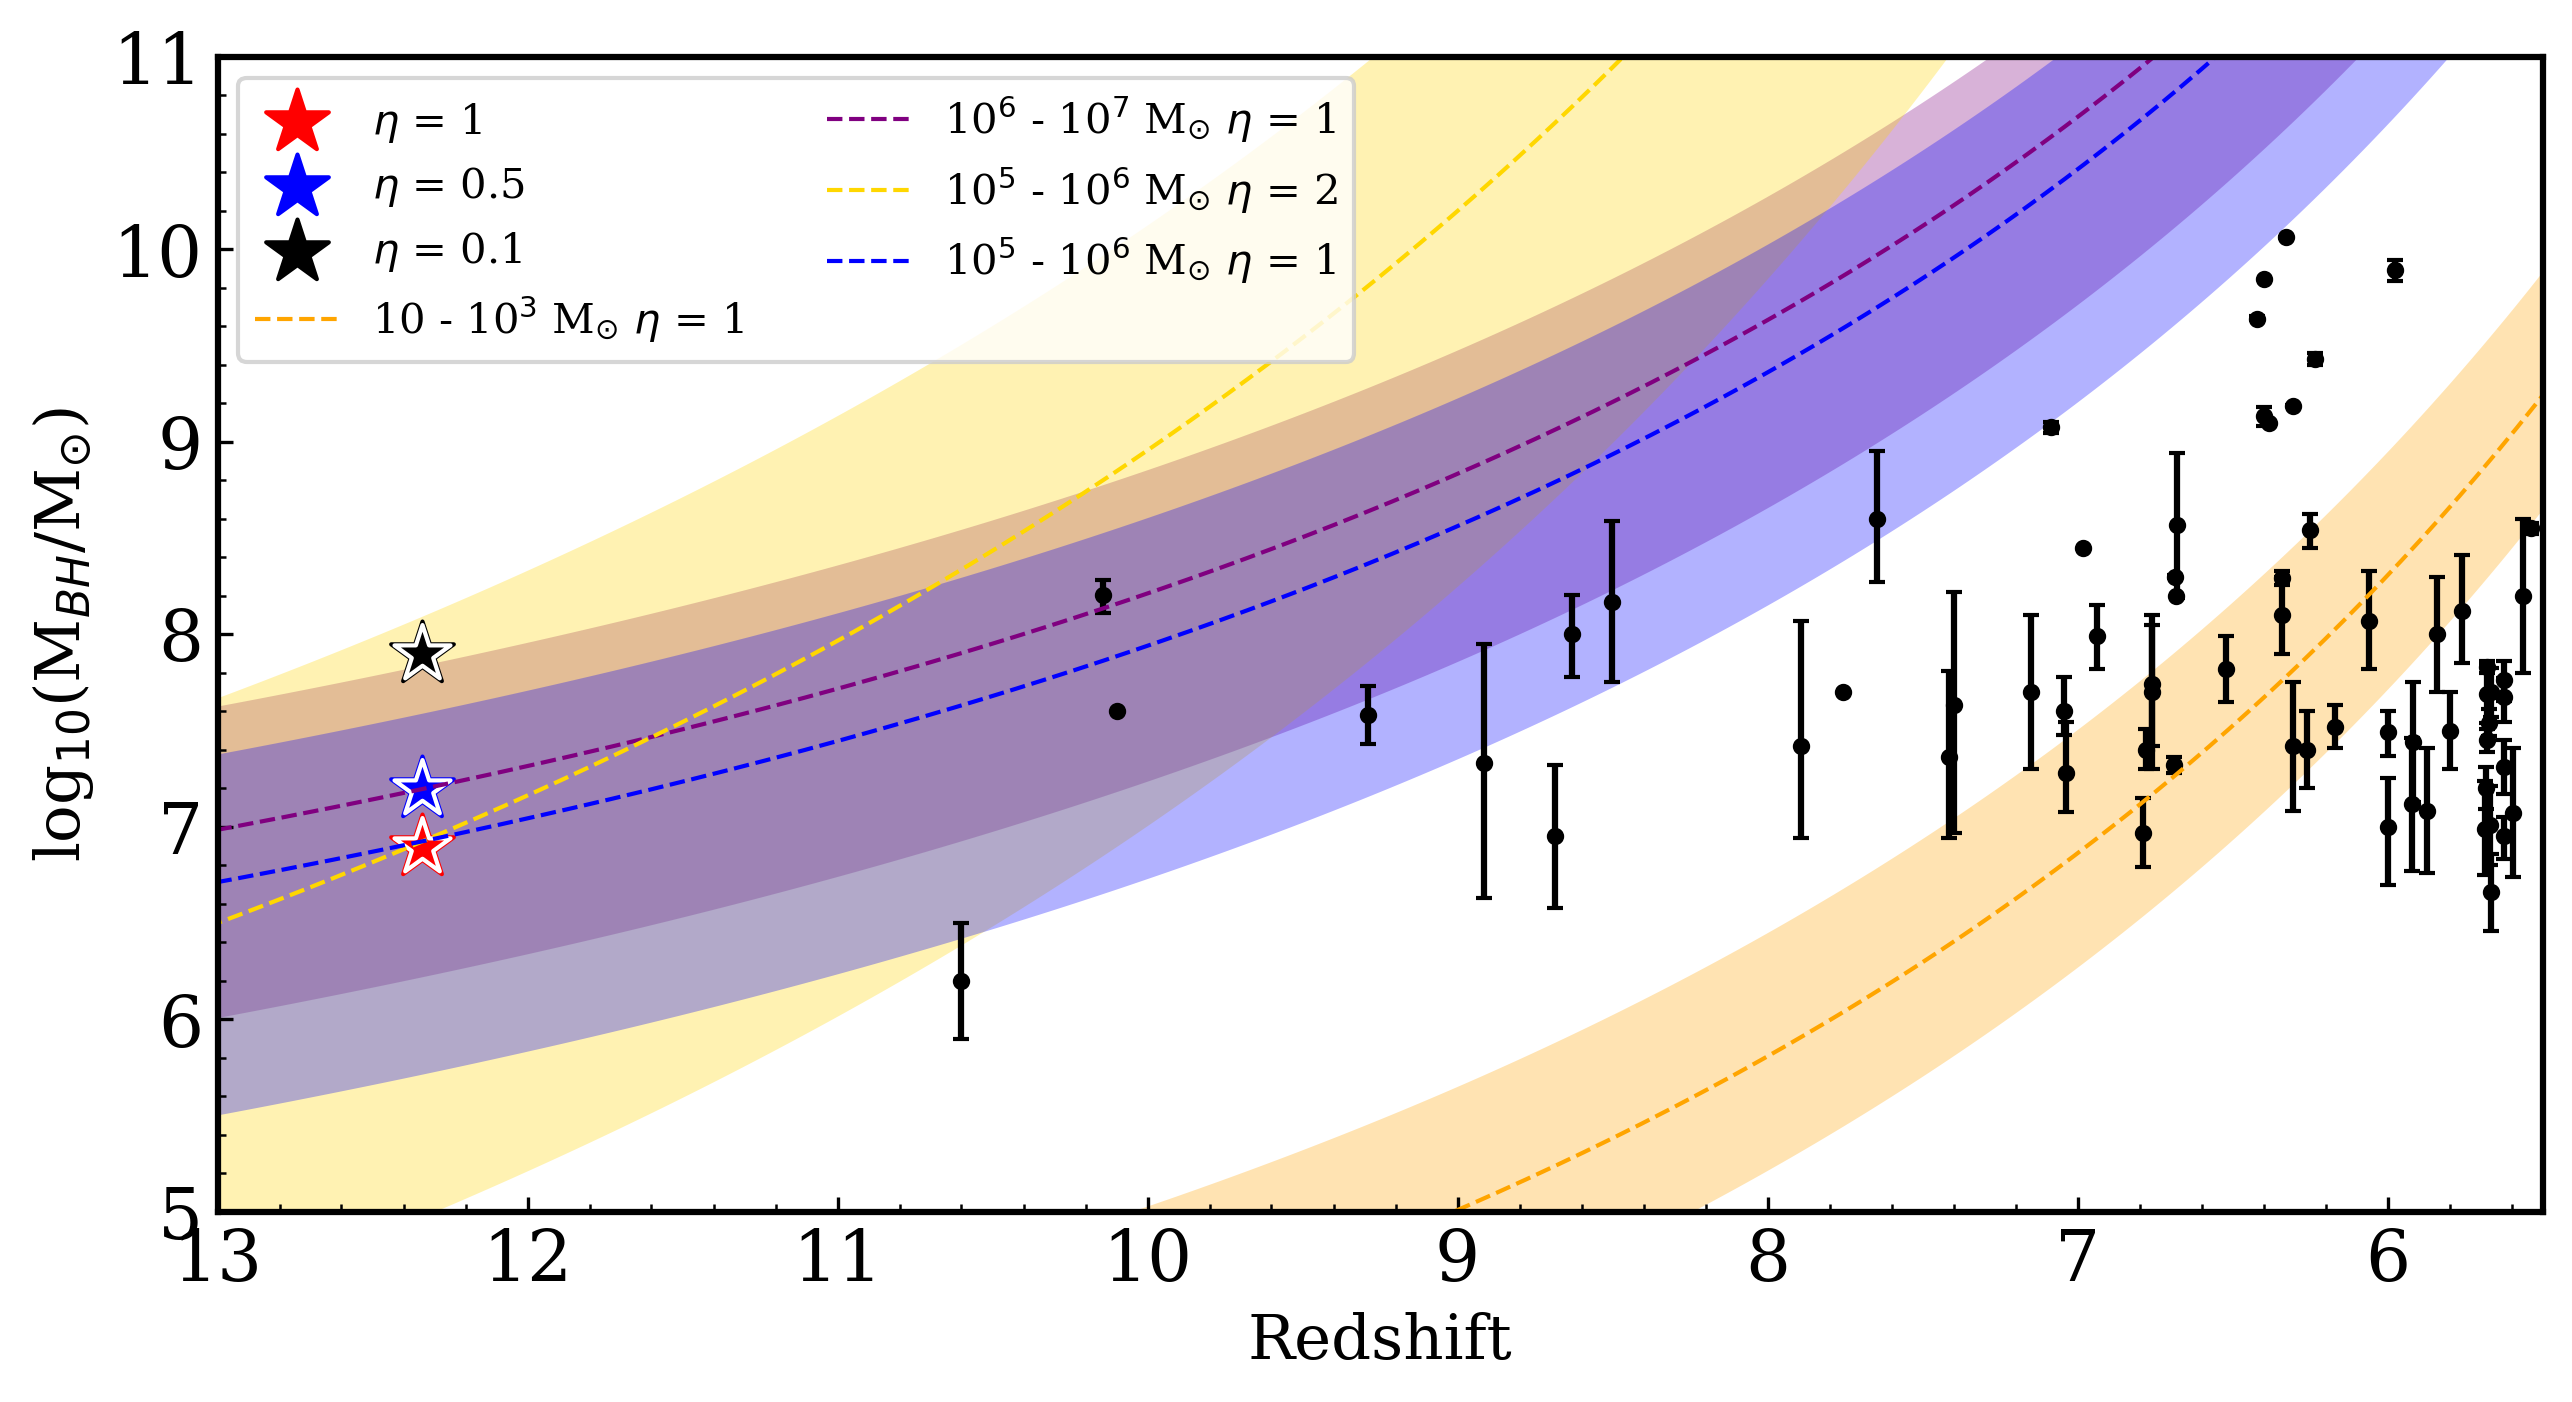

In [56]:
plt.figure(figsize = (10, 5), dpi = 300)
plt.scatter(agn_df.z_spec.values, logMBH, marker = 'o', s= 10, color = 'black')#, label = 'Literature')
plt.errorbar(agn_df.z_spec.values, logMBH, yerr = [lower_error, 
                                                       upper_error], fmt='none', marker= '.', color = 'black', capsize=2)

plt.scatter(12.34, MBH_edd1, color = 'red', marker = '*', s = 250, label = r'$\eta$ = 1')
plt.scatter(12.34, MBH_edd05, color = 'blue', marker = '*', s = 250, label = r'$\eta$ = 0.5')
plt.scatter(12.34, MBH_edd01, color = 'black', marker = '*', s = 250, label = r'$\eta$ = 0.1')
#plt.scatter(12.34, 5.9, color = 'orange')

plt.scatter(12.34, MBH_edd1, color = 'red', marker = '*', s = 200, edgecolors='white')
plt.scatter(12.34, MBH_edd05, color = 'blue', marker = '*', s = 200, edgecolors='white')
plt.scatter(12.34, MBH_edd01, color = 'black', marker = '*', s = 200, edgecolors='white')

#plt.scatter(12.34, MBH_edd2, color = 'purple', marker = '*', s = 200, edgecolors='white')

plt.fill_between(zgrid, np.log10(np.percentile(edd_stellar, 16, axis=0)), 
                                 np.log10(np.percentile(edd_stellar, 84, axis=0)),
                 edgecolor='none', facecolor='orange', alpha=0.3, zorder=-2000)
plt.plot(zgrid, np.log10(np.percentile(edd_stellar, 50, axis=0)), c='orange', 
         lw=1, ls='--', label=r'10 - 10$^3$ M$_{\odot}$ $\eta$ = 1')

# plt.fill_between(zgrid, np.log10(np.percentile(edd_dcbh, 16, axis=0)), 
#                  np.log10(np.percentile(edd_dcbh, 84, axis=0)), edgecolor='none', facecolor='blue', alpha=0.15, zorder=-2000)
# plt.plot(zgrid, np.log10(np.percentile(edd_dcbh, 50, axis=0)), c='blue', lw=1, ls='--', label=r'10$^4$ - 10$^5$ M$_{\odot}$ $\eta$ = 1')

# plt.fill_between(zgrid, np.log10(np.percentile(edd_dcbh2, 16, axis=0)), 
#                                  np.log10(np.percentile(edd_dcbh2, 84, axis=0)), edgecolor='none', facecolor='red', alpha=0.3, zorder=-2000)
# plt.plot(zgrid, np.log10(np.percentile(edd_dcbh2, 50, axis=0)), c='red', lw=1, ls='--', label=r'10$^5$ - 10$^6$ M$_{\odot}$ $\eta$ = 1')

plt.fill_between(zgrid, np.log10(np.percentile(edd_dcbh3, 16, axis=0)), 
                                 np.log10(np.percentile(edd_dcbh3, 84, axis=0)), 
                 edgecolor='none', facecolor='purple', alpha=0.3, zorder=-2000)
plt.plot(zgrid, np.log10(np.percentile(edd_dcbh3, 50, axis=0)), c='purple', 
         lw=1, ls='--', label=r'10$^6$ - 10$^7$ M$_{\odot}$ $\eta$ = 1')


plt.fill_between(zgrid, np.log10(np.percentile(edd_dcbh4, 16, axis=0)), 
                        np.log10(np.percentile(edd_dcbh4, 84, axis=0)), 
                 edgecolor='none', facecolor='gold', alpha=0.3, zorder=-2000)
plt.plot(zgrid, np.log10(np.percentile(edd_dcbh4, 50, axis=0)), c='gold', lw=1, ls='--', label=r'10$^5$ - 10$^6$ M$_{\odot}$ $\eta$ = 2')

plt.fill_between(zgrid, np.log10(np.percentile(edd_dcbh5, 16, axis=0)), 
                        np.log10(np.percentile(edd_dcbh5, 84, axis=0)), 
                 edgecolor='none', facecolor='blue', alpha=0.3, zorder=-2000)
plt.plot(zgrid, np.log10(np.percentile(edd_dcbh5, 50, axis=0)), c='blue', lw=1, ls='--', label=r'10$^5$ - 10$^6$ M$_{\odot}$ $\eta$ = 1')

#ax.set_yscale('log')
plt.xlim(5.5, 13)
plt.gca().invert_xaxis()
plt.ylim(5, 11)

plt.ylabel(r'log$_{10}$(M$_{BH}$/M$_{\odot}$)', fontsize = 15)
plt.minorticks_on()
plt.tick_params(which='both', direction='in')
plt.xlabel('Redshift', fontsize = 15)
plt.legend(fontsize = 10, ncols = 2)

In [46]:
linear_stellar_mass = Mup300_default['gal_prop']['M_star'][-100:]

In [47]:
median_stellar_mass = np.median(linear_stellar_mass)

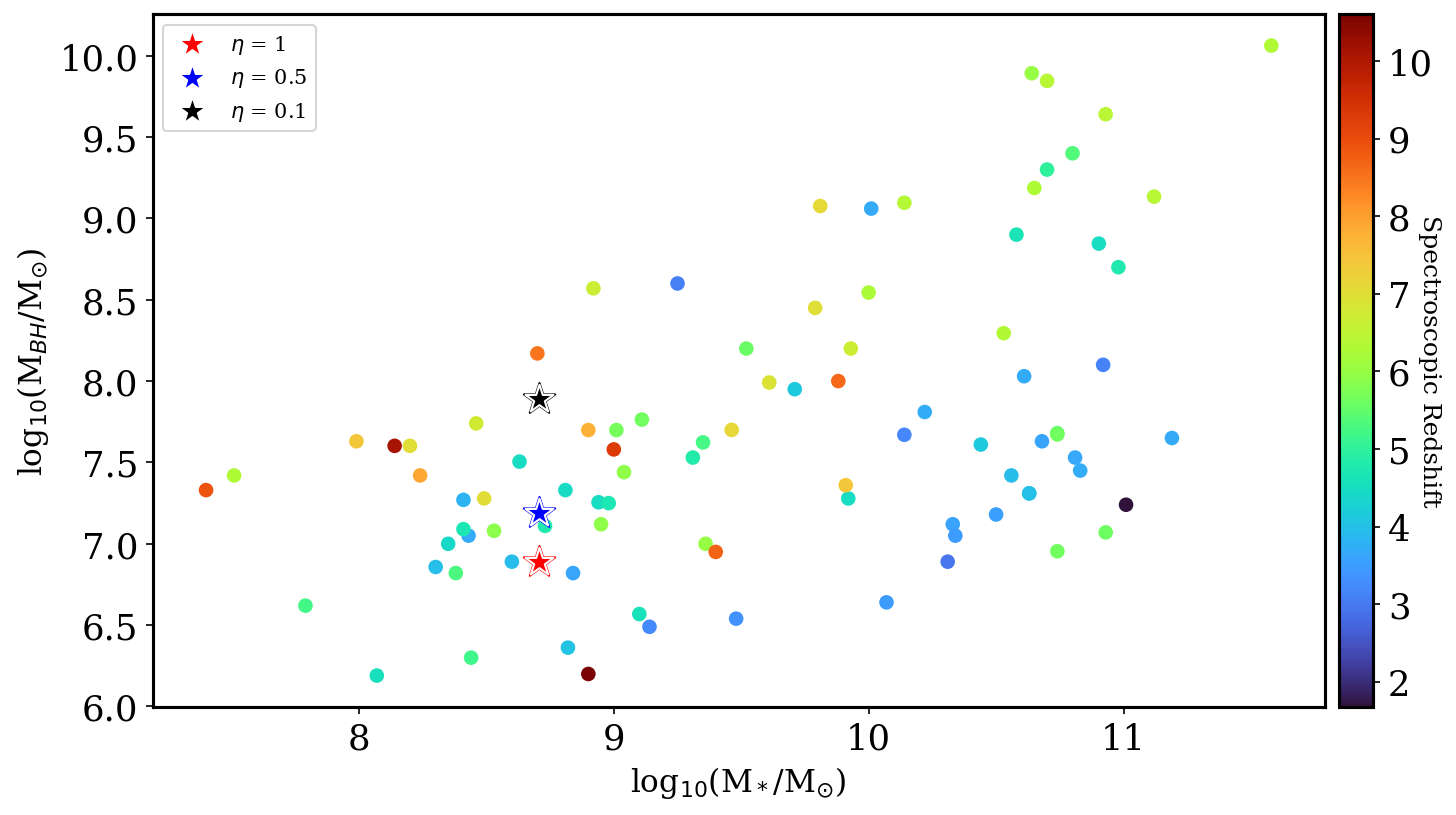

In [58]:
plt.figure(figsize = (12, 6), dpi = 150)
#plt.scatter(new_agn_df.z_spec.values, logMBH, )
#plt.xlabel('Redshift', fontsize = 15)
sc = plt.scatter(log_mstar, logMBH, c = agn_df.z_spec.values, cmap = 'turbo')

plt.scatter(np.log10(median_stellar_mass), MBH_edd1, color = 'red', marker = '*', s = 250)
plt.scatter(np.log10(median_stellar_mass), MBH_edd05, color = 'blue', marker = '*', s = 250)
plt.scatter(np.log10(median_stellar_mass), MBH_edd01, color = 'black', marker = '*', s = 250)

plt.scatter(np.log10(median_stellar_mass), MBH_edd1, marker = '*', color = 'red', s = 200, edgecolors='white', label = r'$\eta$ = 1')
plt.scatter(np.log10(median_stellar_mass), MBH_edd05, color = 'blue', marker = '*', s = 200, edgecolors='white', label = r'$\eta$ = 0.5')
plt.scatter(np.log10(median_stellar_mass), MBH_edd01, color = 'black', marker = '*', s = 200, edgecolors='white', label = r'$\eta$ = 0.1')


plt.xlabel(r'log$_{10}$(M$_*$/M$_{\odot}$)', fontsize = 15)
plt.ylabel(r'log$_{10}$(M$_{BH}$/M$_{\odot}$)', fontsize = 15)

cbar = plt.colorbar(sc, pad=0.01)
cbar.set_label('Spectroscopic Redshift', fontsize=12, rotation = 270)
plt.legend()

plt.savefig('Final_Plots/MBH_vs_Mstar.png', dpi = 300)

In [30]:
def mbh_mstar_relation():

    m_star = np.linspace(7.5, 11, 1000)
    lines = np.zeros((1000, 1000))
    for i in range(1000):
        coeffs = np.random.normal(loc = [1.12, -2.54], scale = [0.08, 0.75])
    
        equation = coeffs[0] * m_star + (coeffs[1])
        lines[i] = equation
    return m_star, lines

def BH_Mass_estimates(bgl_output, eddington_ratio = 1):

    logLacc = np.array(bgl_output['agn_emission']['lacc_AGN']).astype(float)
    L_erg_s = (10**logLacc) * u.erg/u.s
    L_Lsun = L_erg_s.to(u.Lsun)

    Mass = L_Lsun/(3.2e4 * (u.Lsun/u.M_sun))/ eddington_ratio
    return Mass

def local_relation_bhmass():

    alpha = 7.45
    alpha_err = 0.08
    beta = 1.05
    beta_err = 0.11

    rand_alphas = np.random.normal(alpha, alpha_err, size = 1000)
    rand_betas = np.random.normal(beta, beta_err, size = 1000)

    Mstar = np.logspace(7.5, 11, 1000)
    Mstar_matrix = np.log10(np.stack([Mstar for x in range(1000)])/1e11)

    lines = Mstar_matrix *rand_betas.reshape(-1, 1) + rand_alphas.reshape(-1, 1)
    #print(lines)
    l16, med, u84 = np.percentile(lines, q = (16, 50, 84), axis = 0)
    
    return l16, med, u84, Mstar, lines 

In [31]:
def BHMass_Stellar_Mass_Relation(stellar_mass, bhmasses_eddington, bhmasses_pt5_eddington, bhmasses_pt1_eddington, agn_df, lines_highz, lr_l16, lr_med, lr_u84, mstar_lowz, mstar_highz):

    plt.figure(figsize = (8, 5), dpi = 300)

    ##########
    #Plotting out Data
    ########
    plt.scatter(np.log10(np.median(stellar_mass)), np.log10(np.median(bhmasses_eddington.value)), 
                marker = '*', color = 'red', s = 100, zorder = 99, 
                edgecolors='white', label = r'GHZ2 $\eta$: 1')
    plt.scatter(np.log10(np.median(stellar_mass)), np.log10(np.median(bhmasses_eddington.value)), 
                marker = '*', color = 'red', s = 200, zorder = 1)
    
    plt.scatter(np.log10(np.median(stellar_mass)), np.log10(np.median(bhmasses_pt5_eddington.value)), 
                marker = '*', color = 'blue', s = 100, zorder = 99, 
                edgecolors='white', label = r'GHZ2 $\eta$: 0.5')
    plt.scatter(np.log10(np.median(stellar_mass)), np.log10(np.median(bhmasses_pt5_eddington.value)), 
                marker = '*', color = 'blue', s = 200, zorder = 1)
    
    plt.scatter(np.log10(np.median(stellar_mass)), np.log10(np.median(bhmasses_pt1_eddington.value)), 
                marker = '*', color = 'black', s = 100, zorder = 99, 
                edgecolors='white', label = r'GHZ2 $\eta$: 0.1')
    plt.scatter(np.log10(np.median(stellar_mass)), np.log10(np.median(bhmasses_pt1_eddington.value)), 
                marker = '*', color = 'black', s = 200, zorder = 1)
    
    ###########
    #Plotting data from the literature
    ############
    plt.scatter(np.log10(agn_df['m_star']), np.log10(agn_df['m_bh']), color = '#170b3b')
    
    #############
    #Plotting up the High z relation
    plt.fill_between(mstar_highz, np.percentile(lines_highz, axis = 0,  q = 84),  np.percentile(lines_highz, axis = 0,  q = 16), 
                     color = '#603f8b', alpha = 0.5, label = 'High-z BH Relation')
    plt.plot(mstar_highz, np.median(lines_highz, axis = 0), color = 'black')
    
    ###########
    #Plotting up the local relation
    plt.fill_between(np.log10(mstar_lowz), lr_u84,  lr_l16, color = 'salmon', alpha = 0.5, label = 'Local BH Relation')
    
    plt.plot(np.log10(mstar_lowz), lr_med, color = 'black')
    
    plt.xlabel(r'log$_{10}$(M$_{*}$ [M$_{\odot}$])', fontsize = 15)
    plt.ylabel(r'log$_{10}$(M$_{BH}$[M$_{\odot}$])', fontsize = 15)
    
    plt.legend(fontsize = 10, ncols = 2)
    plt.show()

def get_errors_log10(val, lower_err, upper_err):

    lower_error = np.log10(val/(val - lower_err))
    upper_error = np.log10((val + upper_err)/val)

    return lower_error, upper_error

    
def plot_bh_mass_relation(bgl_agn):        
    
    stellar_mass = bgl_agn['gal_prop']['M_star']

    bh_mass_edd1 = BH_Mass_estimates(bgl_agn, eddington_ratio = 1)
    bh_mass_edd05 = BH_Mass_estimates(bgl_agn, eddington_ratio = 0.5)
    bh_mass_edd01 = BH_Mass_estimates(bgl_agn, eddington_ratio = 0.1)
    agn_df = read_agn_df() 
    mstar_highz, lines_highz = mbh_mstar_relation()

    lr_l16, lr_med, lr_u84, mstar, _ = local_relation_bhmass()

    BHMass_Stellar_Mass_Relation(stellar_mass, bh_mass_edd1, bh_mass_edd05, bh_mass_edd01, agn_df, lines_highz, lr_l16, lr_med, lr_u84, mstar, mstar_highz)



In [32]:
def plot_bhmass_vs_redshift(hdu):

    bh_mass_edd1 = np.log10(np.median(BH_Mass_estimates(bgl_agn, eddington_ratio = 1).value))
    bh_mass_edd05 = np.log10(np.median(BH_Mass_estimates(bgl_agn, eddington_ratio = 0.5).value))
    bh_mass_edd01 = np.log10(np.median(BH_Mass_estimates(bgl_agn, eddington_ratio = 0.1).value))

    agn_df = read_agn_df()

    #getting BH Errors Log
    MBH = agn_df.m_bh.values
    MBH_err_plus = agn_df.m_bh_err_plus
    MBH_err_minus = agn_df.m_bh_err_minus

    low_errors, upper_errors = get_errors_log10(MBH, MBH_err_minus, MBH_err_plus)
    MBH_log10 = np.log10(MBH)
    
    fig, ax = plt.subplots(figsize = (10, 5))

    ax.errorbar(agn_df.z_spec.values, MBH_log10, 
                yerr = [low_errors, upper_errors], color = 'black', fmt = 'none')
    ax.scatter(agn_df.z_spec.values, MBH_log10, 
                marker = 'o', color = 'black', label = 'Literature')
    ax.scatter(12.34, bh_mass_edd1, color = 'red', marker = '*', s = 250, label = r'$\eta$ = 1')
    ax.scatter(12.34, bh_mass_edd05, color = 'blue', marker = '*', s = 250, label = r'$\eta$ = 0.5')
    ax.scatter(12.34, bh_mass_edd01, color = 'black', marker = '*', s = 250, label = r'$\eta$ = 0.1')
    
    ax.scatter(12.34, bh_mass_edd1, color = 'red', marker = '*', s = 200, edgecolors='white')
    ax.scatter(12.34, bh_mass_edd05, color = 'blue', marker = '*', s = 200, edgecolors='white')
    ax.scatter(12.34, bh_mass_edd01, color = 'black', marker = '*', s = 200, edgecolors='white')
    ax.set_ylabel(r'log$_{10}$(M$_{BH}$/M$_{\odot}$)', fontsize = 15)
    ax.set_xlabel('Redshift', fontsize = 15)
    ax.legend(fontsize = 10, ncols = 2)
    plt.show()

In [33]:
def plot_bhmass_vs_redshift(bgl_agn):

    bh_mass_edd1 = np.log10(np.median(BH_Mass_estimates(bgl_agn, eddington_ratio = 1).value))
    bh_mass_edd05 = np.log10(np.median(BH_Mass_estimates(bgl_agn, eddington_ratio = 0.5).value))
    bh_mass_edd01 = np.log10(np.median(BH_Mass_estimates(bgl_agn, eddington_ratio = 0.1).value))

    agn_df = read_agn_df()

    #getting BH Errors Log
    MBH = agn_df.m_bh.values
    MBH_err_plus = agn_df.m_bh_err_plus
    MBH_err_minus = agn_df.m_bh_err_minus

    low_errors, upper_errors = get_errors_log10(MBH, MBH_err_minus, MBH_err_plus)
    MBH_log10 = np.log10(MBH)
    
    fig, ax = plt.subplots(figsize = (10, 5), dpi = 300)

    ax.errorbar(agn_df.z_spec.values, MBH_log10, 
                yerr = [low_errors, upper_errors], color = 'black', fmt = 'none')
    ax.scatter(agn_df.z_spec.values, MBH_log10, 
                marker = 'o', color = 'black', label = 'Literature')
    ax.scatter(12.34, bh_mass_edd1, color = 'red', marker = '*', s = 250, label = r'$\eta$ = 1')
    ax.scatter(12.34, bh_mass_edd05, color = 'blue', marker = '*', s = 250, label = r'$\eta$ = 0.5')
    ax.scatter(12.34, bh_mass_edd01, color = 'black', marker = '*', s = 250, label = r'$\eta$ = 0.1')
    
    ax.scatter(12.34, bh_mass_edd1, color = 'red', marker = '*', s = 200, edgecolors='white')
    ax.scatter(12.34, bh_mass_edd05, color = 'blue', marker = '*', s = 200, edgecolors='white')
    ax.scatter(12.34, bh_mass_edd01, color = 'black', marker = '*', s = 200, edgecolors='white')
    ax.set_ylabel(r'log$_{10}$(M$_{BH}$/M$_{\odot}$)', fontsize = 15)
    ax.set_xlabel('Redshift', fontsize = 15)
    ax.legend(fontsize = 10, ncols = 2)
    plt.show()

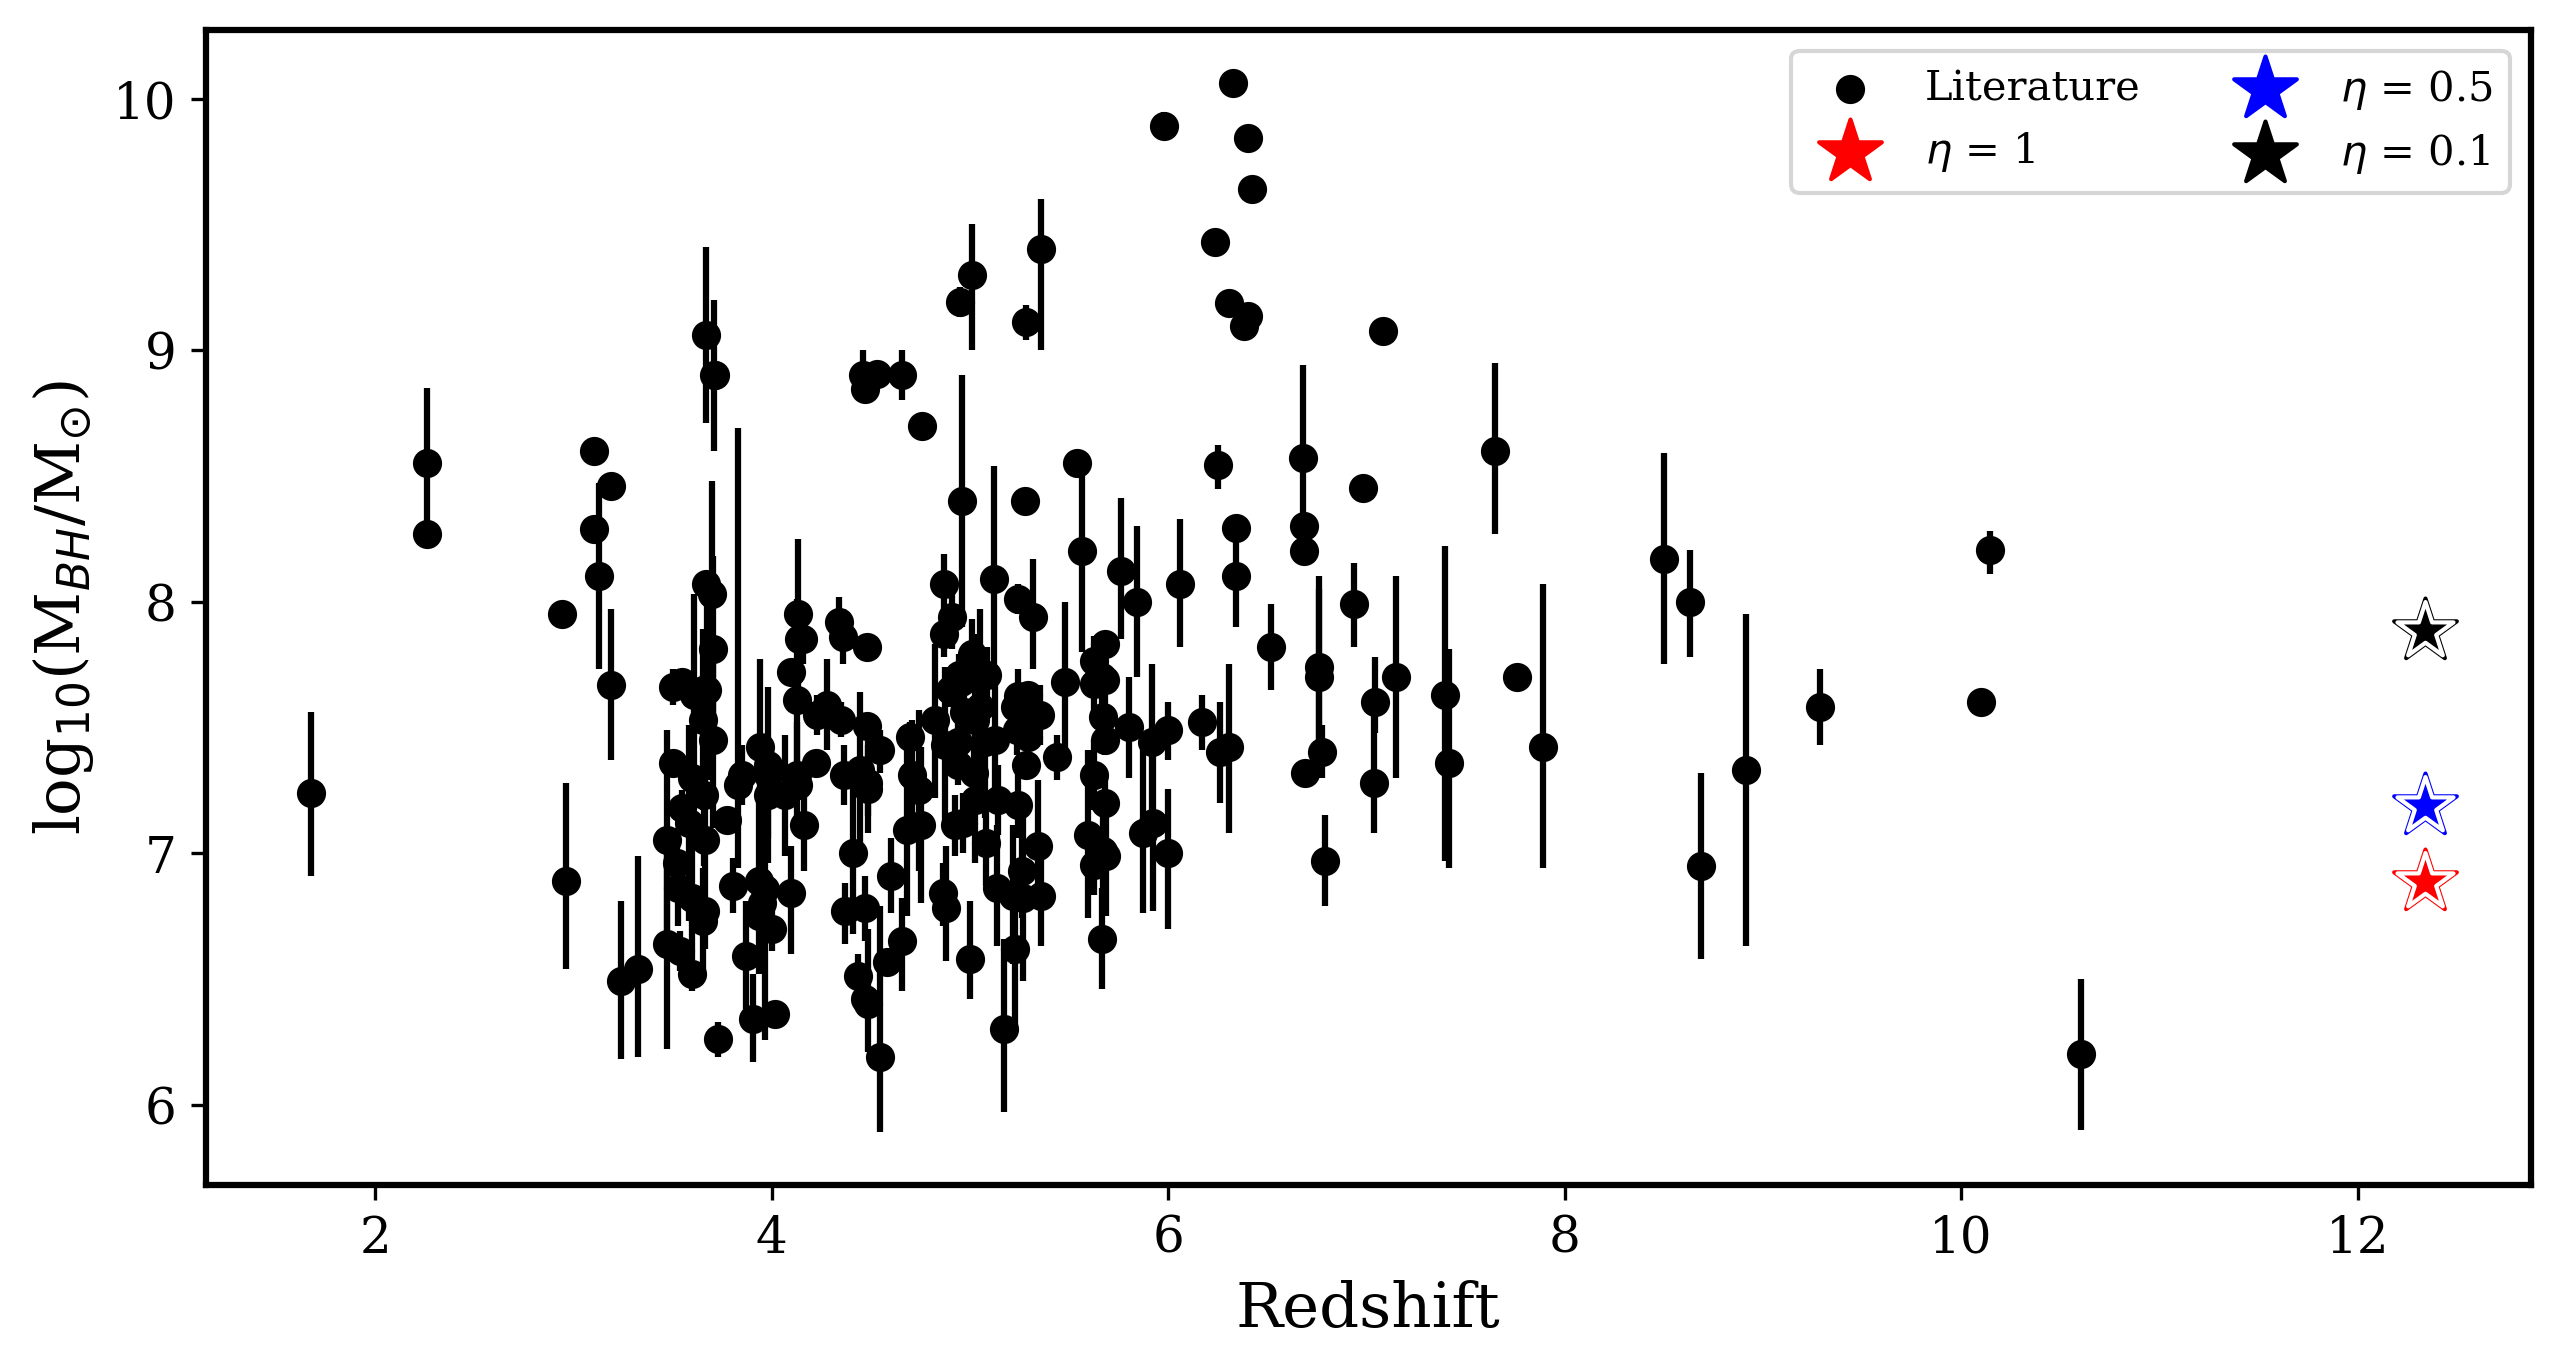

In [89]:
plot_bhmass_vs_redshift(Mup300_default)

In [71]:
bh_mass_edd1 = BH_Mass_estimates(mup100_logU, eddington_ratio = 1)
bh_mass_edd05 = BH_Mass_estimates(mup100_logU, eddington_ratio = 0.5)
bh_mass_edd01 = BH_Mass_estimates(mup100_logU, eddington_ratio = 0.1)

In [36]:
np.percentile(np.log10(bh_mass_edd1.value), q = (16, 50, 84))

array([6.85933766, 6.89831112, 6.93922261])

In [58]:
6.89831112 - 6.85933766

0.03897346000000024

In [66]:
np.percentile(np.log10(bh_mass_edd05.value), q = (16, 50, 84))

array([7.16036765, 7.19934112, 7.2402526 ])

In [60]:
7.19934112 - 7.16036765

0.03897346999999929

In [38]:
np.percentile(np.log10(bh_mass_edd01.value), q = (16, 50, 84))

array([7.85933766, 7.89831112, 7.93922261])

In [62]:
7.89831112 - 7.85933766

0.03897346000000024

In [39]:
np.percentile((bh_mass_edd1.value/mup100_logU['gal_prop']['M_star']),  q= (16, 50, 84))

0.01360575770885904
0.02537399247403319
0.03406087801227481


In [74]:
0.02537 - 0.0136

0.011770000000000001

In [75]:
0.0340 - 0.02537

0.008630000000000002

(array([ 17., 104., 523., 956., 716., 320.,  89.,  23.,  13.,   3.]),
 array([ 5493517.403283  ,  6132684.28767962,  6771851.17207623,
         7411018.05647285,  8050184.94086947,  8689351.82526608,
         9328518.7096627 ,  9967685.59405932, 10606852.47845593,
        11246019.36285255, 11885186.24724917]),
 <BarContainer object of 10 artists>)

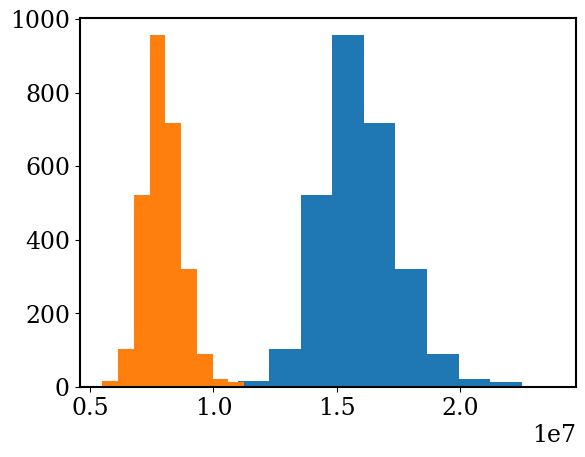

In [72]:
plt.hist(bh_mass_edd05.value)
plt.hist(bh_mass_edd1.value)

In [67]:
np.percentile((bh_mass_edd05.value/mup100_logU['gal_prop']['M_star']),  q= (16, 50, 84))

0.02721151541771808
0.05074798494806638
0.06812175602454962


In [77]:
0.0681 - 0.0507 #- 0.0272

0.017399999999999992

In [65]:
np.percentile((bh_mass_edd01.value/mup100_logU['gal_prop']['M_star']),  q= (16, 50, 84))

0.1360575770885904
0.2537399247403319
0.3406087801227481


In [79]:
0.3406 - 0.2537 #- 0.1361

0.08690000000000003

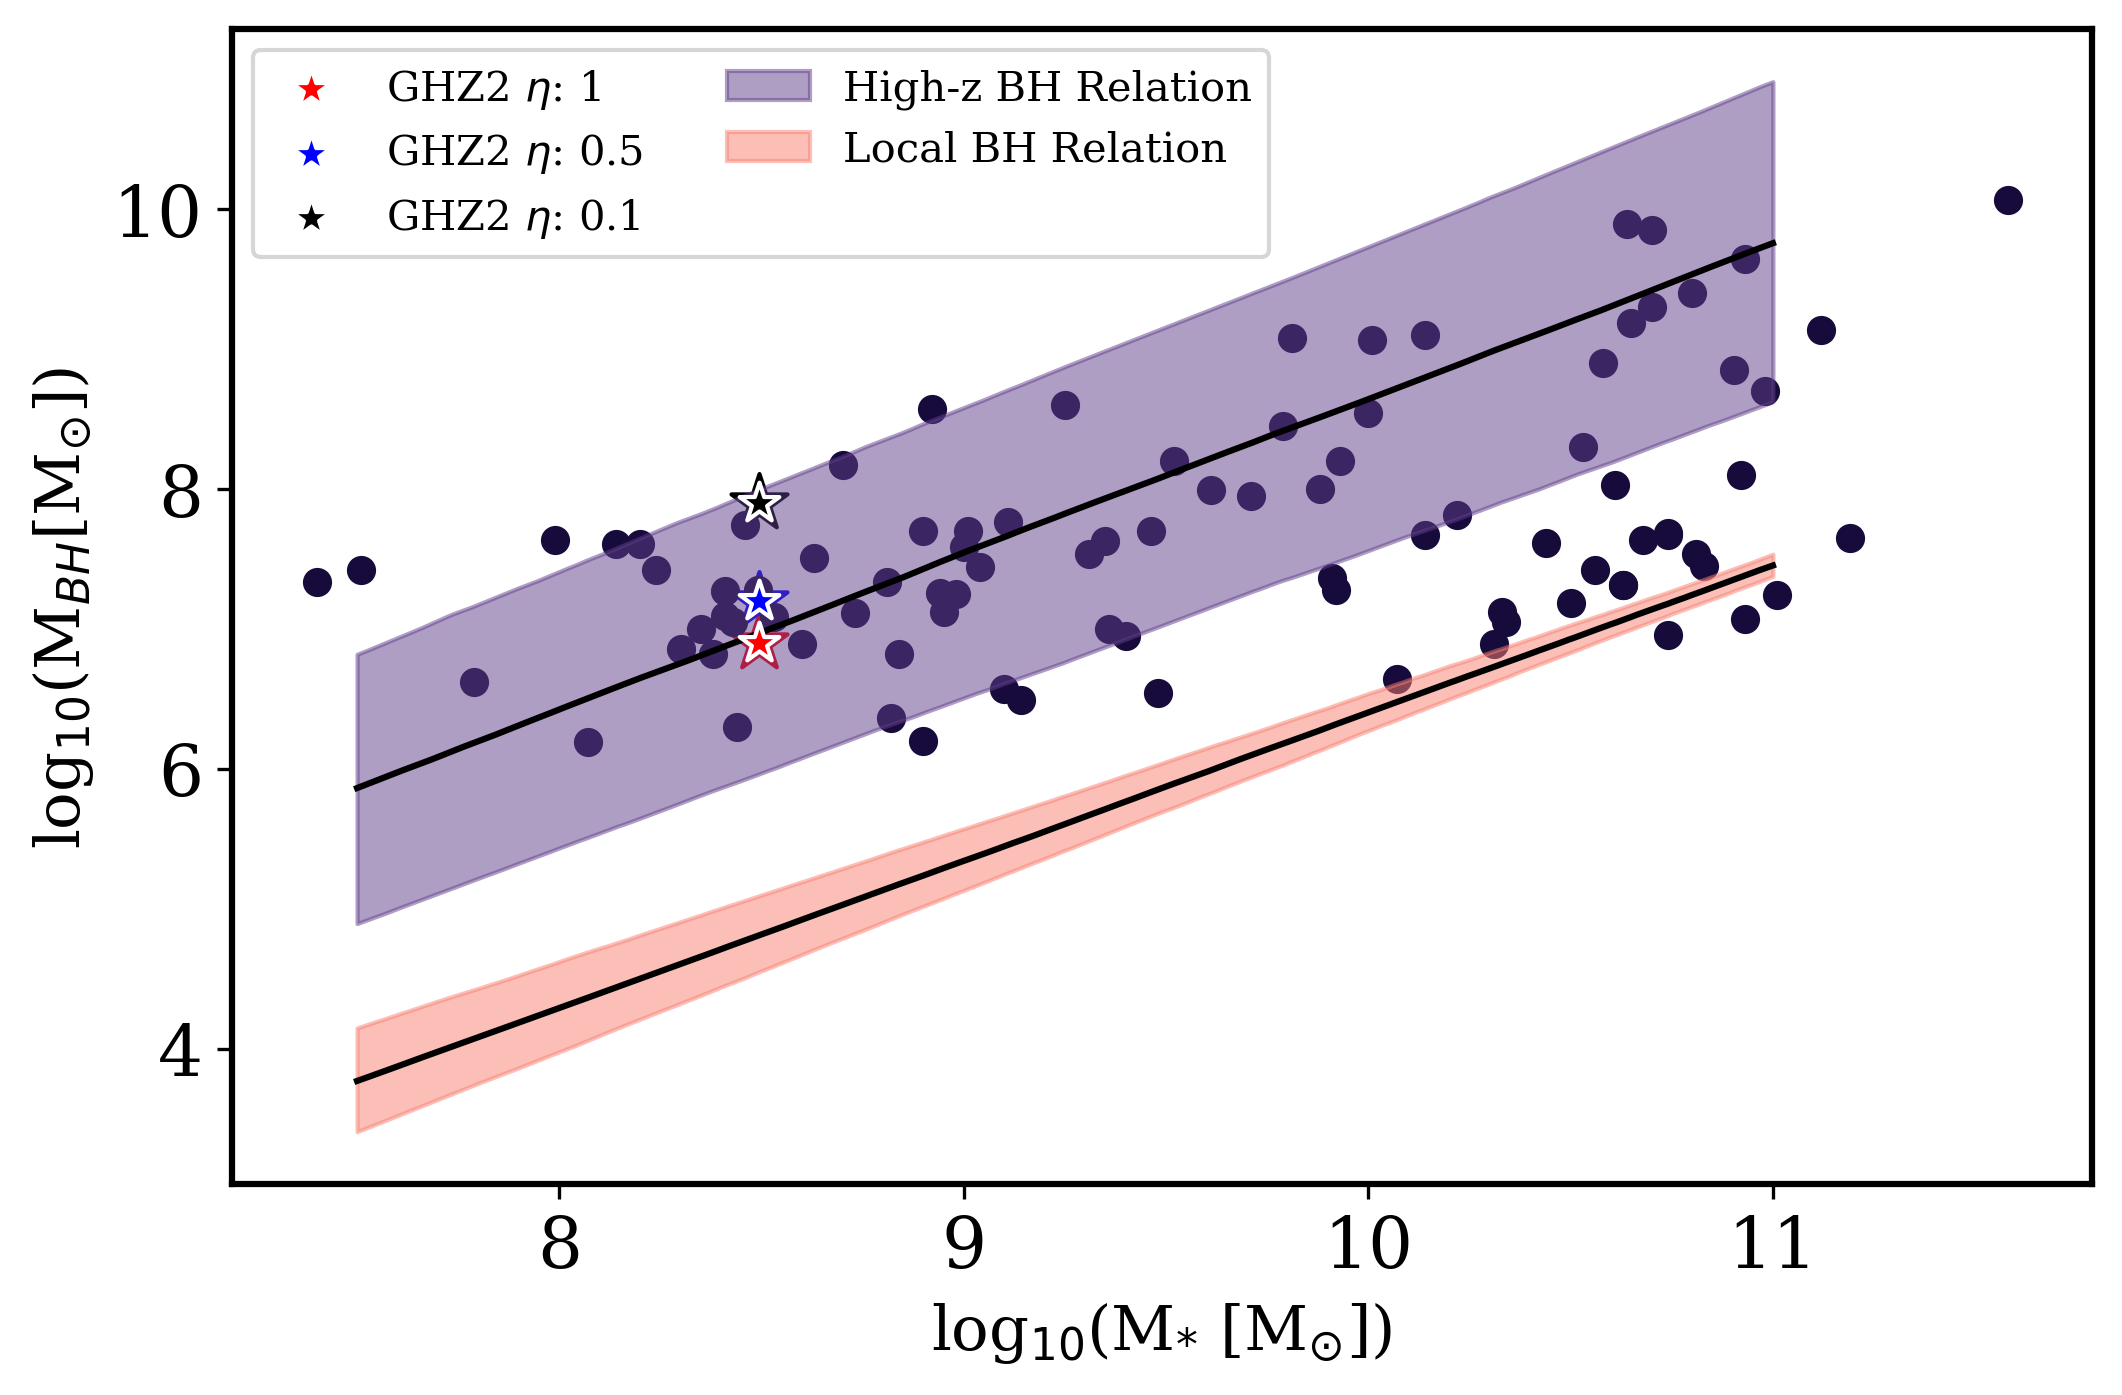

In [34]:
plot_bh_mass_relation(mup100_logU)

In [74]:
# main_plot_components(hdu, wave, flux, fluxerr, plot = True)

In [75]:
# agn_fraction = computing_agn_fraction(hdu, wave)

In [164]:
import pickle

In [182]:
cont_wave, cont_flux = read_continuum_info(hdu)
agn_sed = read_agn(hdu)
full_sed_wave, full_sed = read_full_sed(hdu)
zmax = get_maxlnl_z(hdu)

In [263]:
#agn_fraction, full_agn_conv_seds, full_conv_seds = computing_agn_fraction(hdu, wave, zmax)

Convolving all the FULL SEDs


100%|███████████████████████████████████████| 1187/1187 [01:04<00:00, 18.32it/s]


Convolving all the AGN SEDs


100%|███████████████████████████████████████| 1187/1187 [00:56<00:00, 20.87it/s]
/Users/oac466/Desktop/BEAGLE-general/Analyze_Beagle_Output.py:279: RuntimeWarning: invalid value encountered in divide
  


In [265]:
miri_spectra = pd.read_csv('data/spectra/MIRI_SPECTRA_for_MCMC.txt', sep = ' ', index_col = 0)

In [273]:
conv_miri_arr = convolve_all_seds_miri(full_sed_wave*13.34, full_sed, miri_spectra.wave_AA.values)

precomputing grid


100%|███████████████████████████████████████| 1187/1187 [05:01<00:00,  3.94it/s]


In [285]:
np.save('Convolved_Model_Spectra/Mup100_AGN_Fiducial_Nirspec_Full_SED.npy', full_conv_seds)
np.save('Convolved_Model_Spectra/Mup100_AGN_Fiducial_Nirspec_AGN_SED.npy', full_agn_conv_seds)
np.save('Convolved_Model_Spectra/Agn_Fraction_Nirspec_Fiducial.npy', agn_fraction)

In [287]:
np.save('Convolved_Model_Spectra/Mup100_AGN_Fiducial_MIRI_FULL_SED.npy', conv_miri_arr)

In [289]:
def set_up_plot_panel(hdu, wave, flux, fluxerr):
    
    cont_wave, cont_flux = read_continuum_info(hdu)
    agn_sed = read_agn(hdu)
    full_sed_wave, full_sed = read_full_sed(hdu)
    zmax = get_maxlnl_z(hdu)

    full_conv_seds     = np.load('Convolved_Model_Spectra/Mup100_AGN_Fiducial_Nirspec_Full_SED.npy')
    full_agn_conv_seds = np.load('Convolved_Model_Spectra/Mup100_AGN_Fiducial_Nirspec_AGN_SED.npy')
    agn_fraction       = np.load('Convolved_Model_Spectra/Agn_Fraction_Nirspec_Fiducial.npy')
    conv_miri_arr      = np.load('Convolved_Model_Spectra/Mup100_AGN_Fiducial_MIRI_FULL_SED.npy')
    
    plot_spectra_and_zoom_ins(full_conv_seds, full_agn_conv_seds, 
                              full_sed_wave, full_sed, 
                              cont_wave, agn_sed, 
                              wave, flux, fluxerr, 
                              agn_fraction, 
                              agn_fraction, #should be miri 
                              conv_miri_arr, zmax)

In [291]:
hdu = fits.open('mup100_agn_logu/1395_BEAGLE.fits.gz')

In [283]:
df = Table(hdu['AGN EMISSION'].data).to_pandas()

In [284]:

plot_bhmass_vs_redshift(df)

NameError: name 'plot_bhmass_vs_redshift' is not defined

In [297]:
def get_posterior_df(hdu):

    posterior_df = Table(hdu['POSTERIOR PDF'].data).to_pandas()

    return posterior_df

In [301]:
def compute_bic_region(marg_wave, marg_sed, wave, flux, fluxerr, plot = None, plot_file = None):

    #model_wave, model_flux = read_marg_sed(bgl_output)
    residual = compute_residuals(wave*1e10, flux, fluxerr, marg_wave, marg_sed)
    chi2 = residual**2
    mask = (model_wave > 19000) & (model_wave < 26500)
    L = np.exp(-0.5*np.sum(chi2[mask]))
    lnL = np.log(L)
    n = mask.sum()
    k = len(bgl_output['posterior'].colnames) - 4
    bic = BIC_Criterion(lnL, k, n)
    return bic

In [26]:
import numpy as np

In [21]:
import re
import glob
import numpy as np
import pandas as pd

def extract_logz_from_stats(file_path):
    with open(file_path, 'r') as f:
        for line in f:
            if "Nested Sampling Global Log-Evidence" in line:
                # Extract values using regex
                match = re.search(r'([\-\d.Ee+]+)\s+\+/\-\s+([\d.Ee+]+)', line)
                if match:
                    logZ = float(match.group(1))
                    logZ_err = float(match.group(2))
                    return logZ, logZ_err
    return None, None  # If not found

model_files = {
    #"AGN+SF: Mup100": "Final_Runs/AGN_Mup100_default_anshbranch_13_fixed_pl_MNstats.dat",
    #"AGN+SF: Mup100+CO": "Final_Runs/AGN_Mup100_Nebular_CO_Grids_anshbranch_13_fixed_pl_MNstats.dat",
    "AGN+SF: Mup100+CO": "Final_Runs/AGN_Mup100_Nebular_CO_Grids_w_logU_anshbranch_13_fixed_pl_MNstats.dat",
    "AGN+SF: Mup100 Default": 'Final_Runs/AGN_Mup100_logU_anshbranch_13_fixed_pl_MNstats.dat',
    "AGN+SF: Mup100+n4": "Final_Runs/AGN_Mup100_default_n4_anshbranch_13_fixed_pl_MNstats.dat",

    # "AGN+SF: Mup100_w_oiii": "Final_Runs/AGN_Mup100_default_w_oiii_MNstats.dat",
    # "AGN+SF: Mup100+CO_w_oiii": "Final_Runs/AGN_Mup100_Nebular_CO_w_oiii_MNstats.dat",
    # "AGN+SF: Mup100+CO+ AGN logU_w_oiii": "Final_Runs/AGN_Mup100_logU_CO_w_oiii_MNstats.dat",
    
    #"AGN+SF: Mup300": "Final_Runs/AGN_Mup300_default_anshbranch_13_fixed_pl_MNstats.dat",
    #"AGN+SF: Mup300+CO": "Final_Runs/AGN_Mup300_Nebular_CO_Grids_anshbranch_13_fixed_pl_MNstats.dat",
    "AGN+SF: Mup300 Default": "Final_Runs/AGN_Mup300_logU_anshbranch_13_fixed_pl_MNstats.dat",
    "AGN+SF: Mup300+CO": "Final_Runs/AGN_Mup300_Nebular_CO_Grids_w_logU_anshbranch_13_fixed_pl_MNstats.dat",

    # "AGN+SF: Mup300_w_oiii": "Final_Runs/AGN_Mup300_default_w_oiii_MNstats.dat",
    # "AGN+SF: Mup300+CO_w_oiii": "Final_Runs/AGN_Mup300_Nebular_CO_w_oiii_MNstats.dat",
    # "AGN+SF: Mup300+ AGN logU_w_oiii": "Final_Runs/AGN_Mup300_logU_w_oiii_MNstats.dat",
    # "AGN+SF: Mup300+CO+ AGN logU_w_oiii": "Final_Runs/AGN_Mup300_logU_CO_w_oiii_MNstats.dat",
    
    "SF Mup100": "Final_Runs/SF_Mup100_Default_anshbranch_13_fixed_pl_MNstats.dat",
    "SF Mup300": "Final_Runs/SF_Mup300_Default_anshbranch_13_fixed_pl_MNstats.dat",
    "SF Mup100 + Nebular CO": "Final_Runs/SF_Mup100_Nebular_CO_anshbranch_13_fixed_pl_MNstats.dat",
    "SF Mup300 + Nebular CO": "Final_Runs/SF_Mup300_Nebular_CO_anshbranch_13_fixed_pl_MNstats.dat",
    "SF Mup100 + n4": "Final_Runs/SF_Mup100_Default_n4_anshbranch_13_fixed_pl_MNstats.dat"
}

results = []
for label, file_path in model_files.items():
    logZ, logZ_err = extract_logz_from_stats(file_path)
    if logZ is not None:
        results.append((label, logZ, logZ_err, file_path))

results.sort(key=lambda x: x[1], reverse=True)
top_logZ = results[0][1]

# Convert to DataFrame
df = pd.DataFrame(results, columns=["Model", "logZ", "logZ_err", "File"])
df["Delta_logZ"] = top_logZ - df["logZ"]
df["Bayes Factor"] = np.exp(df["Delta_logZ"])

# print("Model comparison based on Bayesian log-evidence:\n")
# for i, (file, logZ, err) in enumerate(results):
#     print(f"{i+1}. {file}: logZ = {logZ:.2f} ± {err:.2f}")

#Optional: compute Bayes factors between top model and others
top_logZ = results[0][1]
print("\nBayes factors relative to best model:")
for file, logZ, err, filepath in results[1:]:
    delta = top_logZ - logZ
    print(f"{file: <28}: ΔlogZ = {delta:7.2f} → Bayes factor ≈ {round(np.exp(delta), 2)}")


Bayes factors relative to best model:
AGN+SF: Mup300 Default      : ΔlogZ =    0.88 → Bayes factor ≈ 2.42
AGN+SF: Mup100+CO           : ΔlogZ =    1.52 → Bayes factor ≈ 4.55
AGN+SF: Mup300+CO           : ΔlogZ =    1.77 → Bayes factor ≈ 5.88
AGN+SF: Mup100+n4           : ΔlogZ =    4.92 → Bayes factor ≈ 136.93
SF Mup300 + Nebular CO      : ΔlogZ =  150.19 → Bayes factor ≈ 1.6806976532837374e+65
SF Mup100 + Nebular CO      : ΔlogZ =  153.66 → Bayes factor ≈ 5.405417950435912e+66
SF Mup300                   : ΔlogZ =  162.16 → Bayes factor ≈ 2.6698112752757653e+70
SF Mup100                   : ΔlogZ =  165.70 → Bayes factor ≈ 9.19661256155158e+71
SF Mup100 + n4              : ΔlogZ =  172.63 → Bayes factor ≈ 9.353432606323374e+74


-595.2686854024503

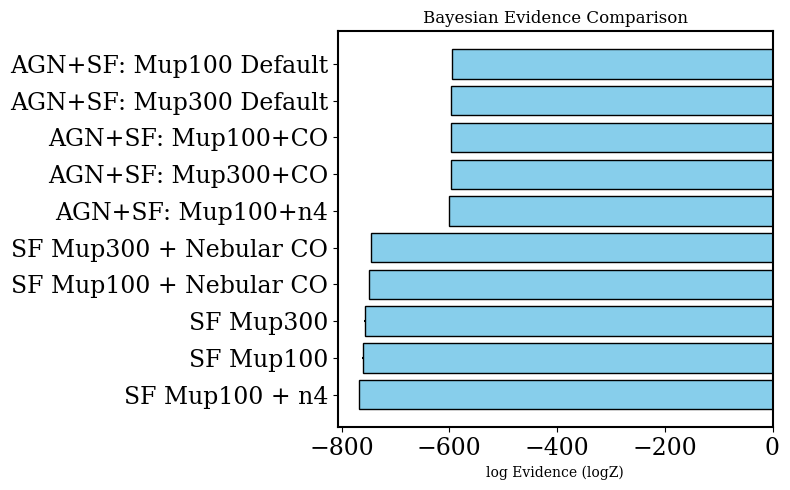

In [22]:
import matplotlib.pyplot as plt

# Assuming `df` is already defined from previous code
plt.figure(figsize=(8, 5))
plt.barh(df["Model"], df["logZ"], xerr=df["logZ_err"], color="skyblue", edgecolor="black")
plt.xlabel("log Evidence (logZ)")
plt.title("Bayesian Evidence Comparison")
plt.gca().invert_yaxis()  # Highest logZ at top
plt.tight_layout()
plt.savefig("logZ_bar_chart.png", dpi=300)
plt.show()

In [78]:
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

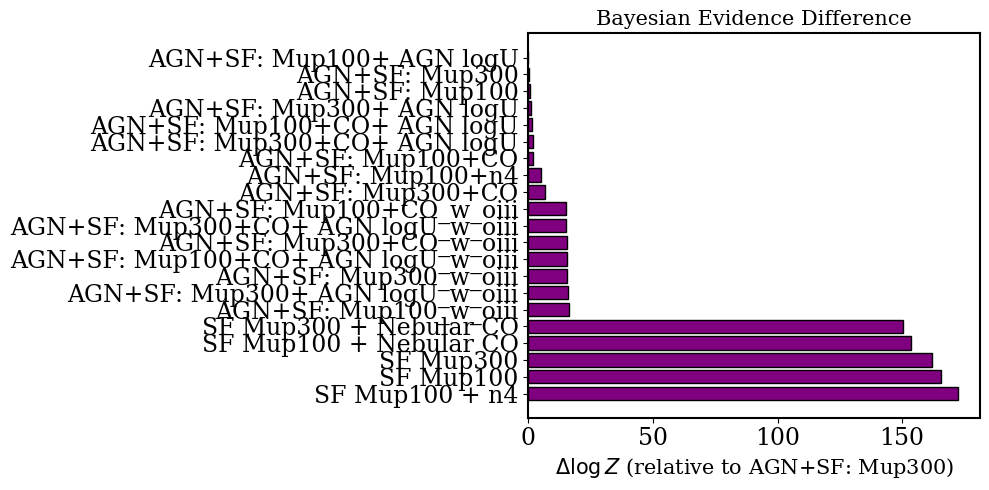

In [11]:
plt.figure(figsize=(10, 5))
plt.barh(df["Model"], df["Delta_logZ"], color="purple", edgecolor="black")
plt.xlabel(r"$\Delta \log Z$ (relative to AGN+SF: Mup300)", fontsize = 15)
plt.title("Bayesian Evidence Difference", fontsize = 15)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("Final_Plots/Bar_Plot_Delta_log_Evidence.png", dpi=300)
plt.show()


,Model,logZ,logZ_err,File,Delta_logZ,Bayes Factor
0,AGN+SF: Mup100+ AGN logU,-595.268685,0.351998,Final_Runs/AGN_Mup100_logU_anshbranch_13_fixed...,0.000000,1.000000e+00
1,AGN+SF: Mup300,-595.440692,0.353169,Final_Runs/AGN_Mup300_default_anshbranch_13_fi...,0.172007,1.187686e+00
2,AGN+SF: Mup100,-595.893752,0.357992,Final_Runs/AGN_Mup100_default_anshbranch_13_fi...,0.625066,1.868370e+00
3,AGN+SF: Mup300+ AGN logU,-596.150868,0.356838,Final_Runs/AGN_Mup300_logU_anshbranch_13_fixed...,0.882183,2.416167e+00
4,AGN+SF: Mup100+CO+ AGN logU,-596.783829,0.350422,Final_Runs/AGN_Mup100_Nebular_CO_Grids_w_logU_...,1.515144,4.550076e+00
5,AGN+SF: Mup300+CO+ AGN logU,-597.040840,0.349345,Final_Runs/AGN_Mup300_Nebular_CO_Grids_w_logU_...,1.772154,5.883514e+00
6,AGN+SF: Mup100+CO,-597.053090,0.350541,Final_Runs/AGN_Mup100_Nebular_CO_Grids_anshbra...,1.784404,5.956030e+00
7,AGN+SF: Mup100+n4,-600.188148,0.350829,Final_Runs/AGN_Mup100_default_n4_anshbranch_13...,4.919463,1.369291e+02
8,AGN+SF: Mup300+CO,-601.908342,0.379989,Final_Runs/AGN_Mup300_Nebular_CO_Grids_anshbra...,6.639656,7.648320e+02
9,SF Mup300 + Nebular CO,-745.455925,0.472744,Final_Runs/SF_Mup300_Nebular_CO_anshbranch_13_...,150.187240,1.680698e+65


In [4]:
mup100_default.convolve_model_spec?

Signature:
mup100_default.convolve_model_spec(
    r_wave,
    r_curve,
    model_wave,
    model_flux,
    wave_obs_spectra,
    oversample=10,
    f_LSF=1,
)
Docstring:
#oversample = define some over-sampling value, I usually use 10 
#f_LSF = fudge factor increasing the resolution by a constant factor, based on e.g. the position in the slit 
         (I usually use ~1.3 or so for point sources)
File:      ~/Desktop/BEAGLE-general/Post_BEAGLE_Analysis.py
Type:      method

In [6]:
g235m_disp = Table.read('jwst_nirspec_g235m_disp.fits')

In [7]:
g235m_disp

WAVELENGTH,DLDS,R
MICRONS,MICRONS/PIXEL,RESOLUTION
float32,float32,float32
1.5,0.0010704668,636.93536
1.502,0.0010704632,637.78674
1.504,0.0010704596,638.6382
1.506,0.001070456,639.48956
1.508,0.0010704524,640.341
1.51,0.0010704487,641.19244
1.512,0.001070445,642.0439
1.514,0.0010704413,642.8954


In [8]:
r_wave, R = g235m_disp['WAVELENGTH'], g235m_disp['R']